In [1]:
import os
import wandb
import pickle
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
os.environ['WANDB_API_KEY'] = "TODO"

In [3]:
proj = "ICL-Functions"

In [4]:
api = wandb.Api()
tag_filter = {
    "$and": [
        {"tags": {"$in": ["ICML_Low_Rank", "ICML_BilinearMLR", "ICML_BilinearBTT", "ICML_Low_Rank_1head", "ICML_Low_Rank_1head_SP_scaling"]}},
        {"tags": {"$nin": ["deprecated", "bad_lr"]}}
    ]
}

runs = api.runs(proj, filters=tag_filter, order='-created_at')

In [5]:
all_data = {}
# param_data = {}

for run in runs:
    pointwise_loss_tag = f"eval_pointwise/loss.{run.config['n_positions']-1}"
    
    history = run.history(keys=["eval/non_emb_compute", pointwise_loss_tag])
    history["run_id"] = run.id

    # unified str_name for all structures
    str_name = f"lr{run.config['training_learning_rate']}_dm_{run.config['d_model']}_nh_{run.config['n_head']}_ndims_{run.config['n_dims']}"

    if run.config['token_mixing_struct']=="bilinear_BTT":
        str_name = f"BilinearBTT_" + str_name
    elif run.config['token_mixing_struct']=="bilinear_MLR":
        rank_per_level = list(map(int, run.config['mlr_rank_list'].split("|")))
        str_name = f"MLR_{len(rank_per_level)}_Levels_{run.config['mlr_rank_list']}_" + str_name
    elif run.config['token_mixing_struct']=="low_rank":
        str_name = f"LowRank_" + str_name
            
    all_data[str_name] = history
    
    # param_data[str_name] = run.config["non_emb_params"]

with open("icl_regression_all_data.pkl", "wb") as file:
    pickle.dump(all_data, file)


In [6]:
for key in all_data:
    print(key)

LowRank_lr5e-05_dm_16_nh_1_ndims_64
LowRank_lr5e-05_dm_64_nh_1_ndims_64
BilinearBTT_lr2.5e-05_dm_32_nh_8_ndims_16
BilinearBTT_lr1e-05_dm_128_nh_8_ndims_64
LowRank_lr0.0001_dm_512_nh_1_ndims_32
LowRank_lr5e-05_dm_512_nh_1_ndims_128
LowRank_lr5e-05_dm_256_nh_1_ndims_128
LowRank_lr5e-05_dm_128_nh_1_ndims_128
LowRank_lr0.0001_dm_16_nh_1_ndims_128
LowRank_lr0.0001_dm_64_nh_1_ndims_128
LowRank_lr5e-05_dm_32_nh_1_ndims_128
LowRank_lr5e-05_dm_256_nh_1_ndims_32
LowRank_lr5e-05_dm_64_nh_1_ndims_32
LowRank_lr5e-05_dm_32_nh_1_ndims_32
LowRank_lr5e-05_dm_128_nh_1_ndims_32
LowRank_lr0.0001_dm_16_nh_1_ndims_32
LowRank_lr5e-05_dm_64_nh_1_ndims_16
LowRank_lr5e-05_dm_32_nh_1_ndims_16
LowRank_lr0.0001_dm_512_nh_1_ndims_16
LowRank_lr5e-05_dm_256_nh_1_ndims_64
BilinearBTT_lr0.0001_dm_1024_nh_8_ndims_32
BilinearBTT_lr0.0001_dm_512_nh_8_ndims_32
BilinearBTT_lr0.0001_dm_256_nh_8_ndims_32
BilinearBTT_lr5e-05_dm_128_nh_8_ndims_32
BilinearBTT_lr5e-05_dm_64_nh_8_ndims_32
LowRank_lr0.0001_dm_1024_nh_8_ndims_32
Bil

## Style

In [7]:
# Use a serif font for academic styling
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 16,
})

def subsample_log(data_x, data_y, num_points=50):
    """
    Subsamples data points in a logarithmic scale.
    Args:
        data_x (array-like): X-axis data points (log scale).
        data_y (array-like): Y-axis data points corresponding to X.
        num_points (int): Number of points to subsample.
    Returns:
        (array-like, array-like): Subsampled x and y points.
    """
    # Filter out zero or negative values in data_x
    data_x = np.array(data_x)
    data_y = np.array(data_y)
    mask = data_x > 0
    data_x = data_x[mask]
    data_y = data_y[mask]

    if len(data_x) <= num_points:
        return data_x, data_y  # Return as is if fewer points

    # Generate indices for subsampling
    log_indices = np.geomspace(0, len(data_x) - 1, num_points).astype(int)
    return data_x[log_indices], data_y[log_indices]


## Low Rank Bottleneck

In [65]:
# Use a serif font for academic styling
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 18,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 16,
})

plt.style.use('seaborn-v0_8-paper')

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif=['Times'])


ndims_64+dm_256 | steps = 189
ndims_64+dm_256 | steps = 189
ndims_64+dm_256 | steps = 95
ndims_64+dm_256 | steps = 91
ndims_64+dm_256 | steps = 89
MLR_4_Levels_8|4|4|16_lr0.0001_dm_256_nh_8_ndims_64
ndims_64+dm_256 | steps = 189


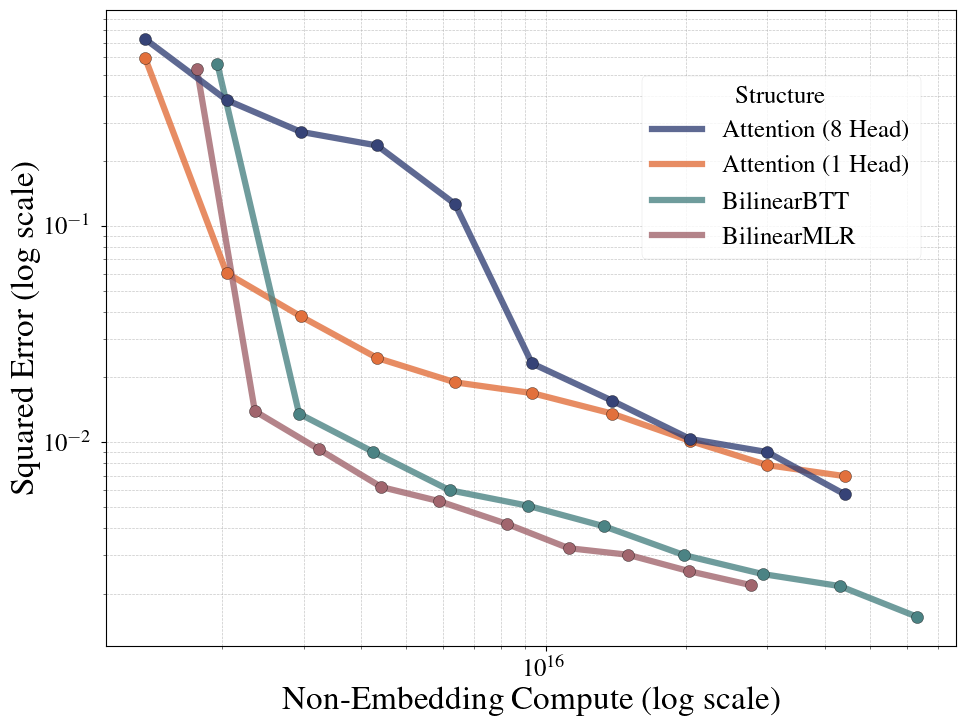

In [85]:
list_of_token_mixing_struct = ['BilinearBTT', 'LowRank', 'MLR']
list_of_ndims = [f"ndims_{i}" for i in [64]]
list_of_dm = [f"dm_{i}" for i in [256]]
subsample=True
num_samples_log_scale=10

# Define a better color palette | Melody | https://github.com/SabrinaSun1225/ChromaPalette
# color_palette = {
#     "BilinearBTT": "#FBB45C",  
#     "LowRank_1h": "#8FA2DC",      
#     "LowRank_8h": "#206491", 
#     "MLR": "#4CC9B0",
#     # "MLR": "#81D0BB"
# }

color_palette = {
    "BilinearBTT": "#4B8384",  
    "LowRank_1h": "#E2703C",      
    "LowRank_8h": "#364377", 
    "MLR": "#A1656D",
    # "MLR": "#81D0BB"
}

colors_MLR_1levels = ["#C6D3E7", "#7E86A7", "#6571A3", "#364377"]
colors_MLR_8levels = ["#ECD4CC", "#E2BABC", "#C58A93", "#A1656D"]
colors_LR_GSWA = ["#D9F1F0", "#AEDCDC", "#6EB0AF", "#4B8384"]
colors_LR_SWA = ["#FFE4D6", "#FFC5A3", "#FF9F6D", "#E2703C"]


# Mapping keys to legend-friendly names
legend_mapping = {
    "BilinearBTT": "BilinearBTT",
    "LowRank_1h": "Attention (1 Head)",
    "LowRank_8h": "Attention (8 Head)",
    "MLR": "BilinearMLR"
}




for ndims in list_of_ndims:
    fig, axes = plt.subplots(1,1, figsize=(10,8), sharex=False, sharey=True)
    # axes = axes.flatten()  # Flatten the axes array for easier indexing

    for i, dm in enumerate(list_of_dm):
        # Create two subplots for each dm: one for loss vs. steps and one for loss vs. non-embedding compute
        # ax_loss_steps = axes[i+6]
        # ax_loss_compute = axes[i]

        for key in all_data:
            if ndims in key and dm in key:
                if 'eval/non_emb_compute' not in all_data[key] or '_step' not in all_data[key]:
                    print(f"Key error | {key}")
                else:
                    print(f"{ndims}+{dm} | steps = {len(all_data[key]['eval/non_emb_compute'])}")

                    # Assign colors and markers for different structures
                    if "BilinearBTT" in key:
                        color, marker = color_palette["BilinearBTT"], "o"
                        legend_label = legend_mapping["BilinearBTT"]
                    elif "LowRank" in key:
                        if "nh_1" in key:
                            color, marker = color_palette["LowRank_1h"], "s"
                            legend_label = legend_mapping["LowRank_1h"]
                        elif "nh_8" in key:
                            color, marker = color_palette["LowRank_8h"], "s"
                            legend_label = legend_mapping["LowRank_8h"]
                    elif "MLR" in key: # and "8|4|4|16" in key:
                        if "8|4|4|16" in key:
                            print(key)
                            color, marker = color_palette["MLR"], "^"
                            legend_label = legend_mapping["MLR"]
                        else: 
                            continue
                    else:
                        raise ValueError

                    x = np.array(all_data[key]['eval/non_emb_compute'])
                    y = np.array(all_data[key][f"eval_pointwise/loss.{int(ndims.split('_')[-1]) * 2 - 1}"])

                    # # Sort x and y for proper log spacing
                    if subsample:
                        sorted_indices = np.argsort(x)
                        x = x[sorted_indices]
                        y = y[sorted_indices]
        
                        # Perform logarithmic subsampling
                        log_x = np.log10(x)  # Convert x to log scale
                        log_x_subsampled = np.linspace(log_x[0], log_x[-1], num_samples_log_scale)  # Evenly spaced in log scale
                        x_subsampled = 10 ** log_x_subsampled  # Convert back to original scale
        
                        # Find the closest points in the original data for the subsampled log points
                        subsample_indices = [np.abs(x - xi).argmin() for xi in x_subsampled]
                        x_subsampled = x[subsample_indices]
                        y_subsampled = y[subsample_indices]
                        
                        # Plot loss vs. non-embedding compute
                        axes.loglog(
                            x_subsampled,
                            y_subsampled,
                            label=legend_label,
                            color=color,
                            # marker=marker,
                            markersize=5,
                            linewidth=4.5,
                            alpha=0.8
                        )
                        axes.scatter(x_subsampled, y_subsampled, color=color, s=75, edgecolor="black", facecolor=color, zorder=3)

                    else:
    
                        # Plot loss vs. non-embedding compute
                        axes.loglog(
                            x,
                            y,
                            label=legend_label,
                            color=color,
                            marker=marker,
                            markersize=5,
                            linewidth=4.5,
                            alpha=0.8
                        )

        axes.set_xlabel("Non-Embedding Compute (log scale)", fontsize=24)
        axes.set_ylabel("Squared Error (log scale)", fontsize=24)

        # axes.set_title(f"Model Width = {dm.split('_')[-1]}", fontsize=24)

    handles, labels = [], []
    ax_handles, ax_labels = axes.get_legend_handles_labels()
    handles.extend(ax_handles)
    labels.extend(ax_labels)

    # Increase the size of the x-ticks and y-ticks
    axes.tick_params(axis='both', which='major', labelsize=18)  # Major ticks
    axes.tick_params(axis='both', which='minor', labelsize=18)  # Minor ticks

    by_label = dict(zip(labels, handles))
    # Desired order of keys
    desired_order = ['Attention (8 Head)', 'Attention (1 Head)', 'BilinearBTT', 'BilinearMLR']
    
    # Sort the dictionary based on the desired order
    by_label = {key: by_label[key] for key in desired_order if key in by_label}

    # from collections import OrderedDict

    # # Move the last key to the front
    # last_key = list(by_label.keys())[-1]
    # by_label = OrderedDict([(last_key, None)] + [(k, None) for k in by_label if k != last_key])

    fig.legend(
        by_label.values(),
        by_label.keys(),
        # loc="lower center",
        # bbox_to_anchor=(0.5, -0.2),
        bbox_to_anchor=(0.95, 0.85),

        # ncol=4,
        title="Structure",
        fontsize=18,
        title_fontsize=18,
    )
    # fig.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
    plt.grid(visible=True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.savefig(f"selected_rank_bottleneck_in_low_rank.pdf", dpi=300, bbox_inches="tight")
    plt.show()



In [67]:
labels

['Attention (1 Head)', 'BilinearBTT', 'BilinearMLR', 'Attention (8 Head)']

In [68]:
by_label

{'Attention (8 Head)': <matplotlib.lines.Line2D at 0x32fd5dfd0>,
 'Attention (1 Head)': <matplotlib.lines.Line2D at 0x313e09760>,
 'BilinearBTT': <matplotlib.lines.Line2D at 0x32fd5c7a0>,
 'BilinearMLR': <matplotlib.lines.Line2D at 0x32fd5de80>}

ndims_16+dm_16 | steps = 191
ndims_16+dm_16 | steps = 191
ndims_16+dm_16 | steps = 191
ndims_16+dm_32 | steps = 191
ndims_16+dm_32 | steps = 191
ndims_16+dm_32 | steps = 191
ndims_16+dm_64 | steps = 191
ndims_16+dm_64 | steps = 191
ndims_16+dm_64 | steps = 191
ndims_16+dm_128 | steps = 191
ndims_16+dm_128 | steps = 191
ndims_16+dm_128 | steps = 191
ndims_16+dm_256 | steps = 191
ndims_16+dm_256 | steps = 191
ndims_16+dm_256 | steps = 191
ndims_16+dm_512 | steps = 191
ndims_16+dm_512 | steps = 191
ndims_16+dm_512 | steps = 191


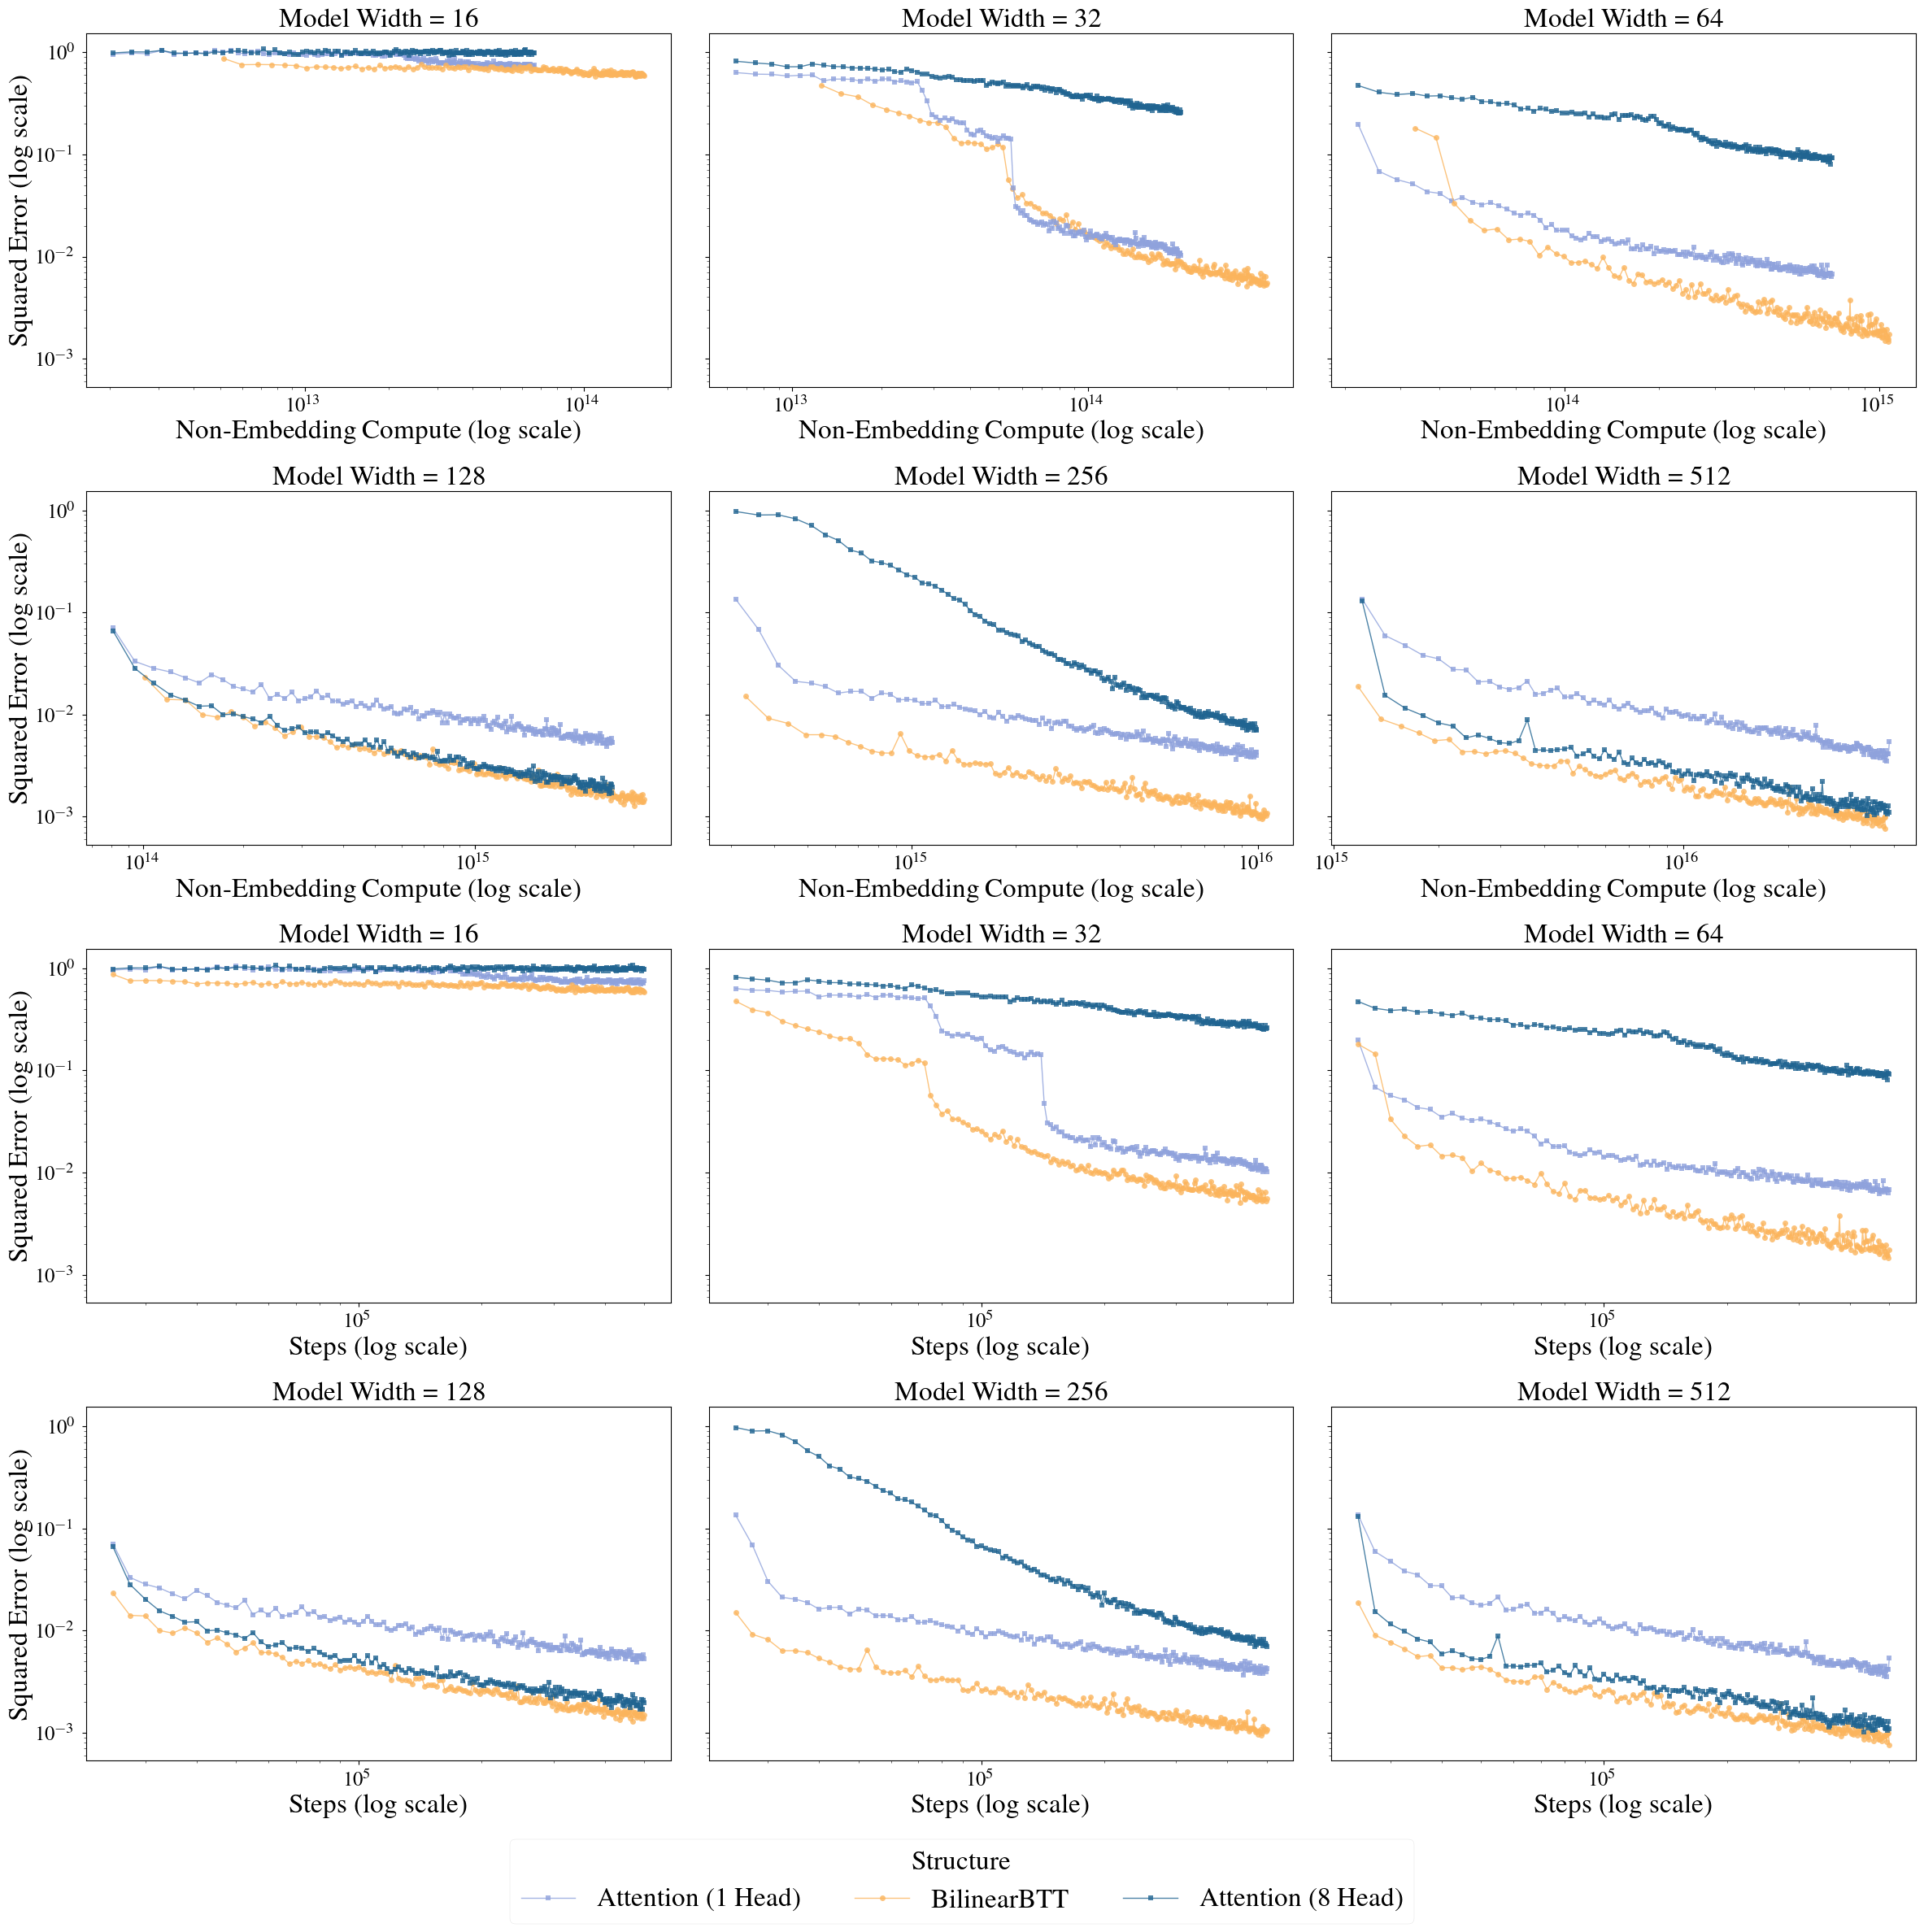

ndims_32+dm_16 | steps = 189
ndims_32+dm_16 | steps = 189
ndims_32+dm_16 | steps = 189
ndims_32+dm_32 | steps = 189
ndims_32+dm_32 | steps = 189
ndims_32+dm_32 | steps = 189
ndims_32+dm_64 | steps = 189
ndims_32+dm_64 | steps = 189
ndims_32+dm_64 | steps = 189
ndims_32+dm_128 | steps = 189
ndims_32+dm_128 | steps = 189
ndims_32+dm_128 | steps = 189
ndims_32+dm_256 | steps = 189
ndims_32+dm_256 | steps = 189
ndims_32+dm_256 | steps = 189
ndims_32+dm_512 | steps = 189
ndims_32+dm_512 | steps = 189
ndims_32+dm_512 | steps = 189


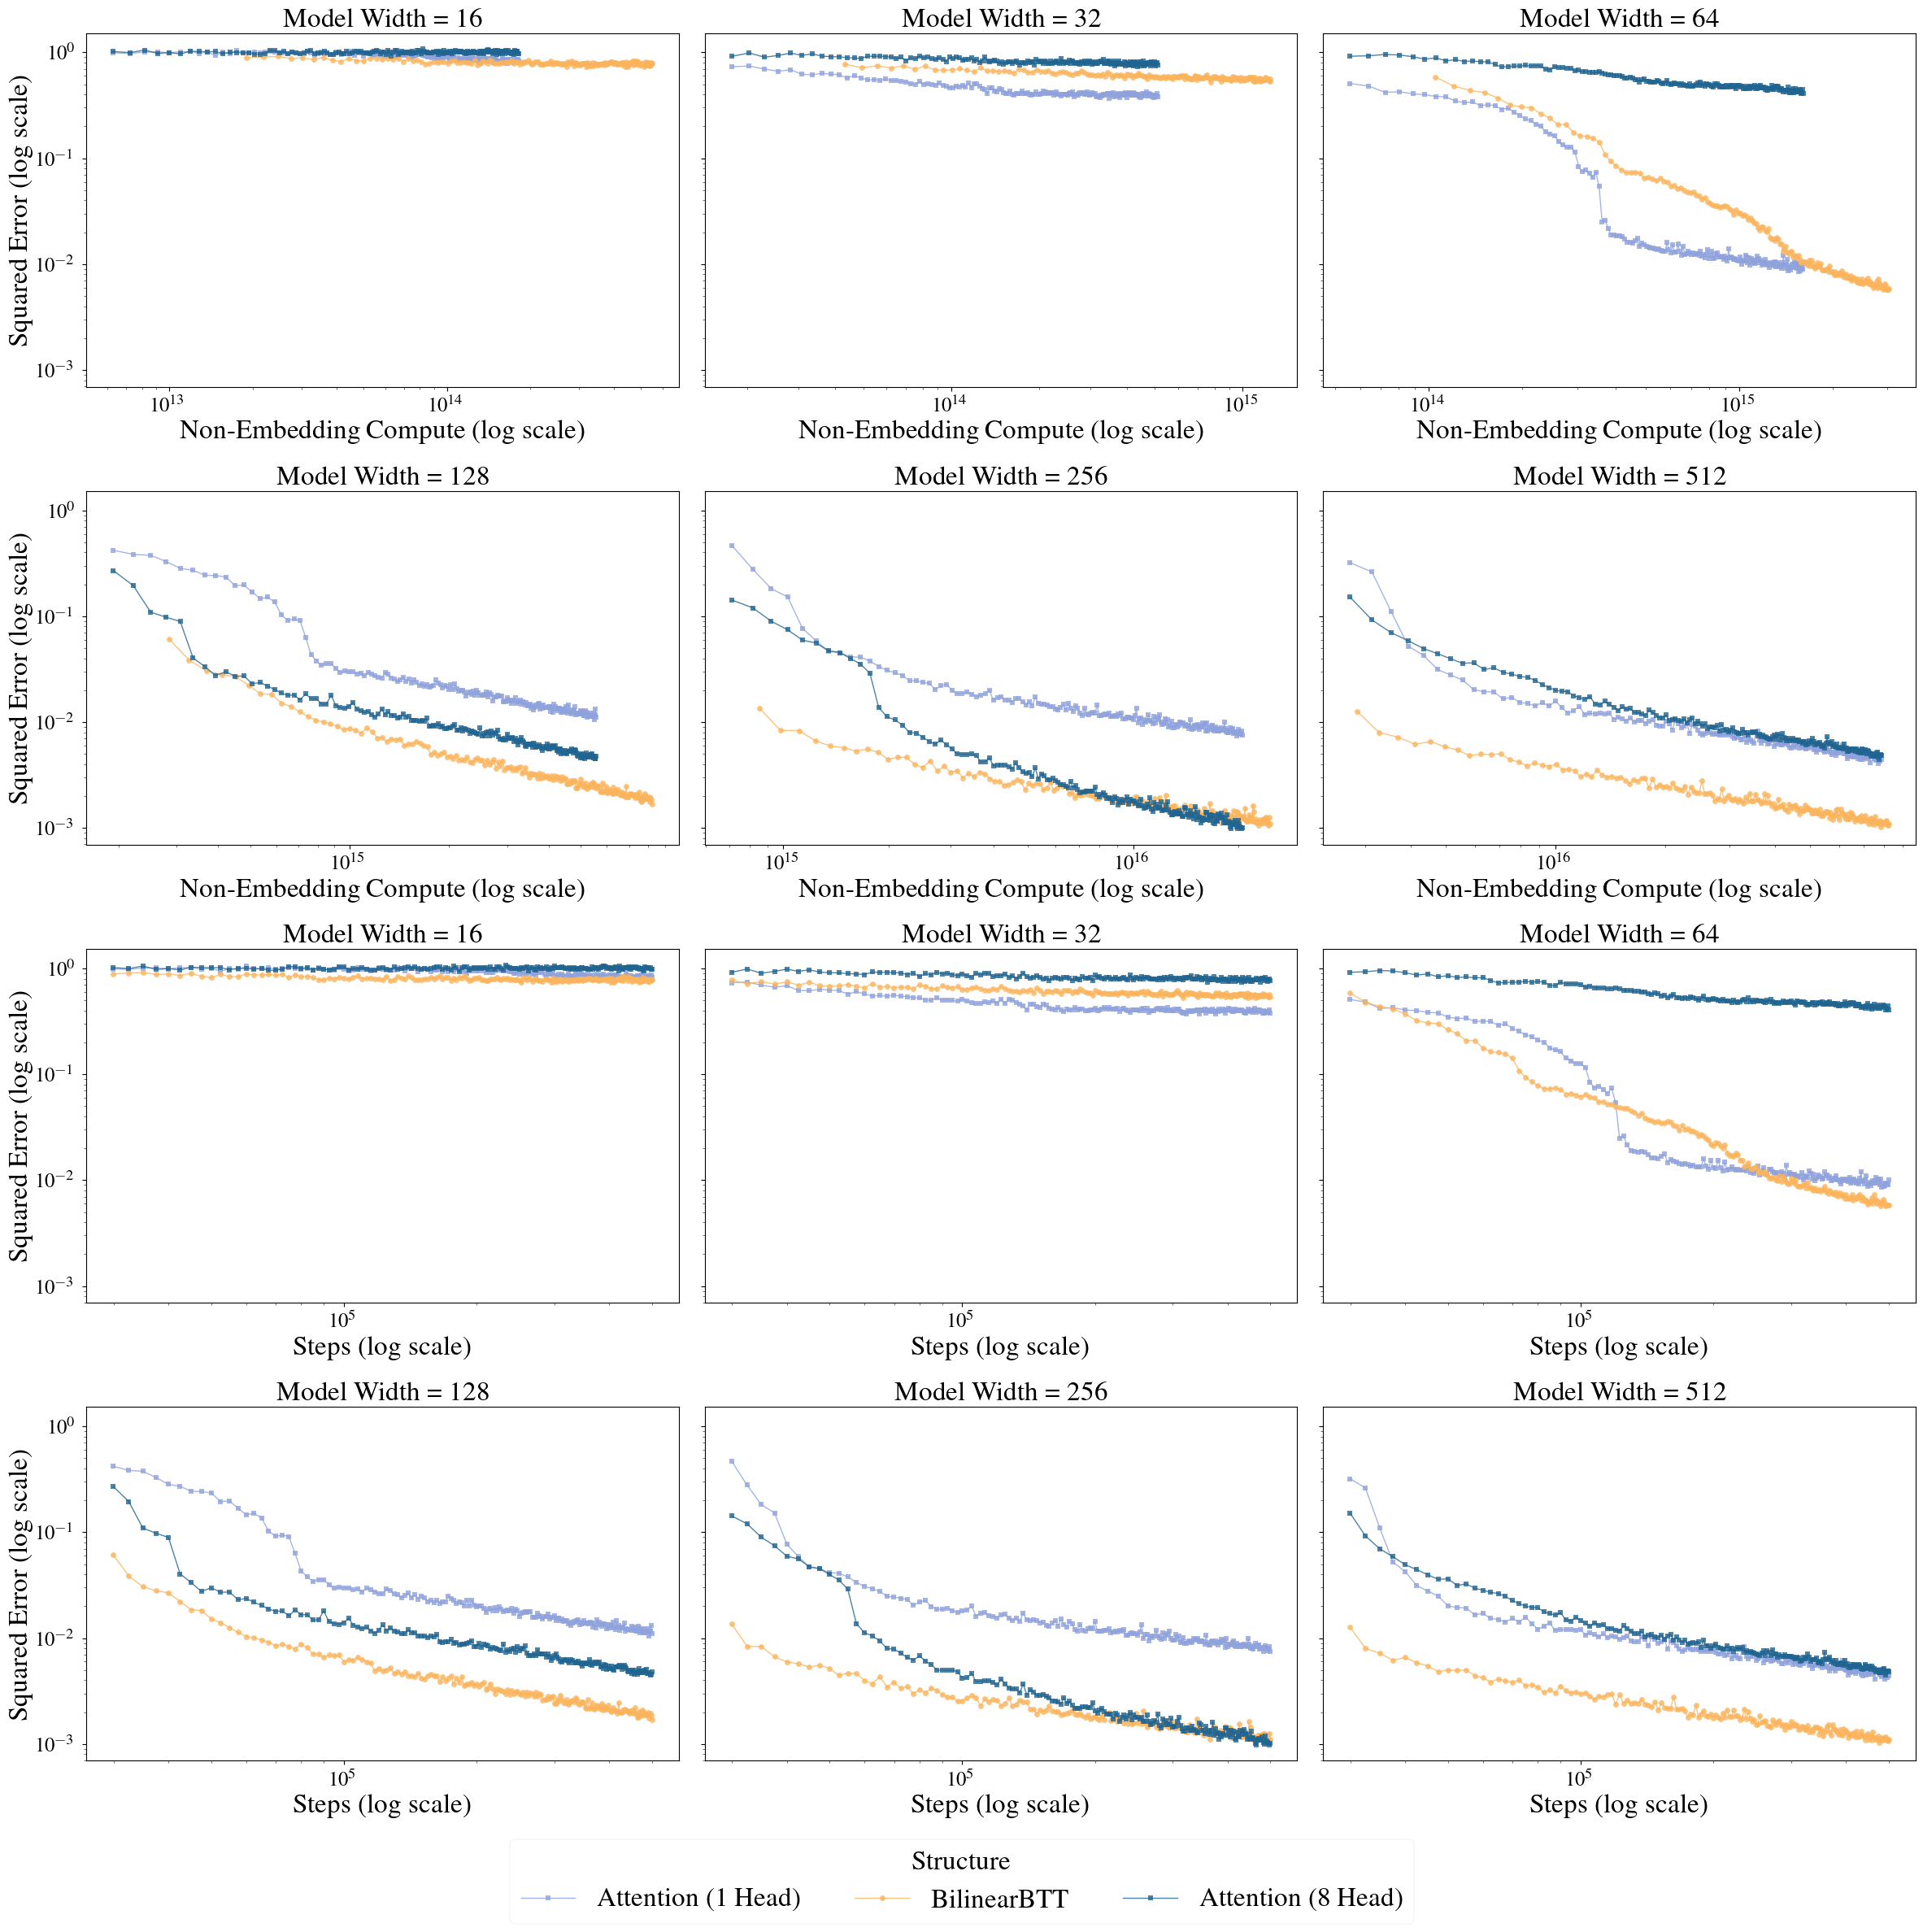

ndims_64+dm_16 | steps = 189
ndims_64+dm_16 | steps = 189
ndims_64+dm_16 | steps = 189
ndims_64+dm_32 | steps = 189
ndims_64+dm_32 | steps = 189
ndims_64+dm_32 | steps = 189
ndims_64+dm_64 | steps = 189
ndims_64+dm_64 | steps = 189
ndims_64+dm_64 | steps = 189
ndims_64+dm_128 | steps = 189
ndims_64+dm_128 | steps = 189
ndims_64+dm_128 | steps = 189
ndims_64+dm_256 | steps = 189
ndims_64+dm_256 | steps = 189
ndims_64+dm_256 | steps = 95
ndims_64+dm_256 | steps = 91
ndims_64+dm_256 | steps = 89
ndims_64+dm_256 | steps = 189
ndims_64+dm_512 | steps = 189
ndims_64+dm_512 | steps = 90
ndims_64+dm_512 | steps = 115
ndims_64+dm_512 | steps = 42
ndims_64+dm_512 | steps = 42
ndims_64+dm_512 | steps = 42


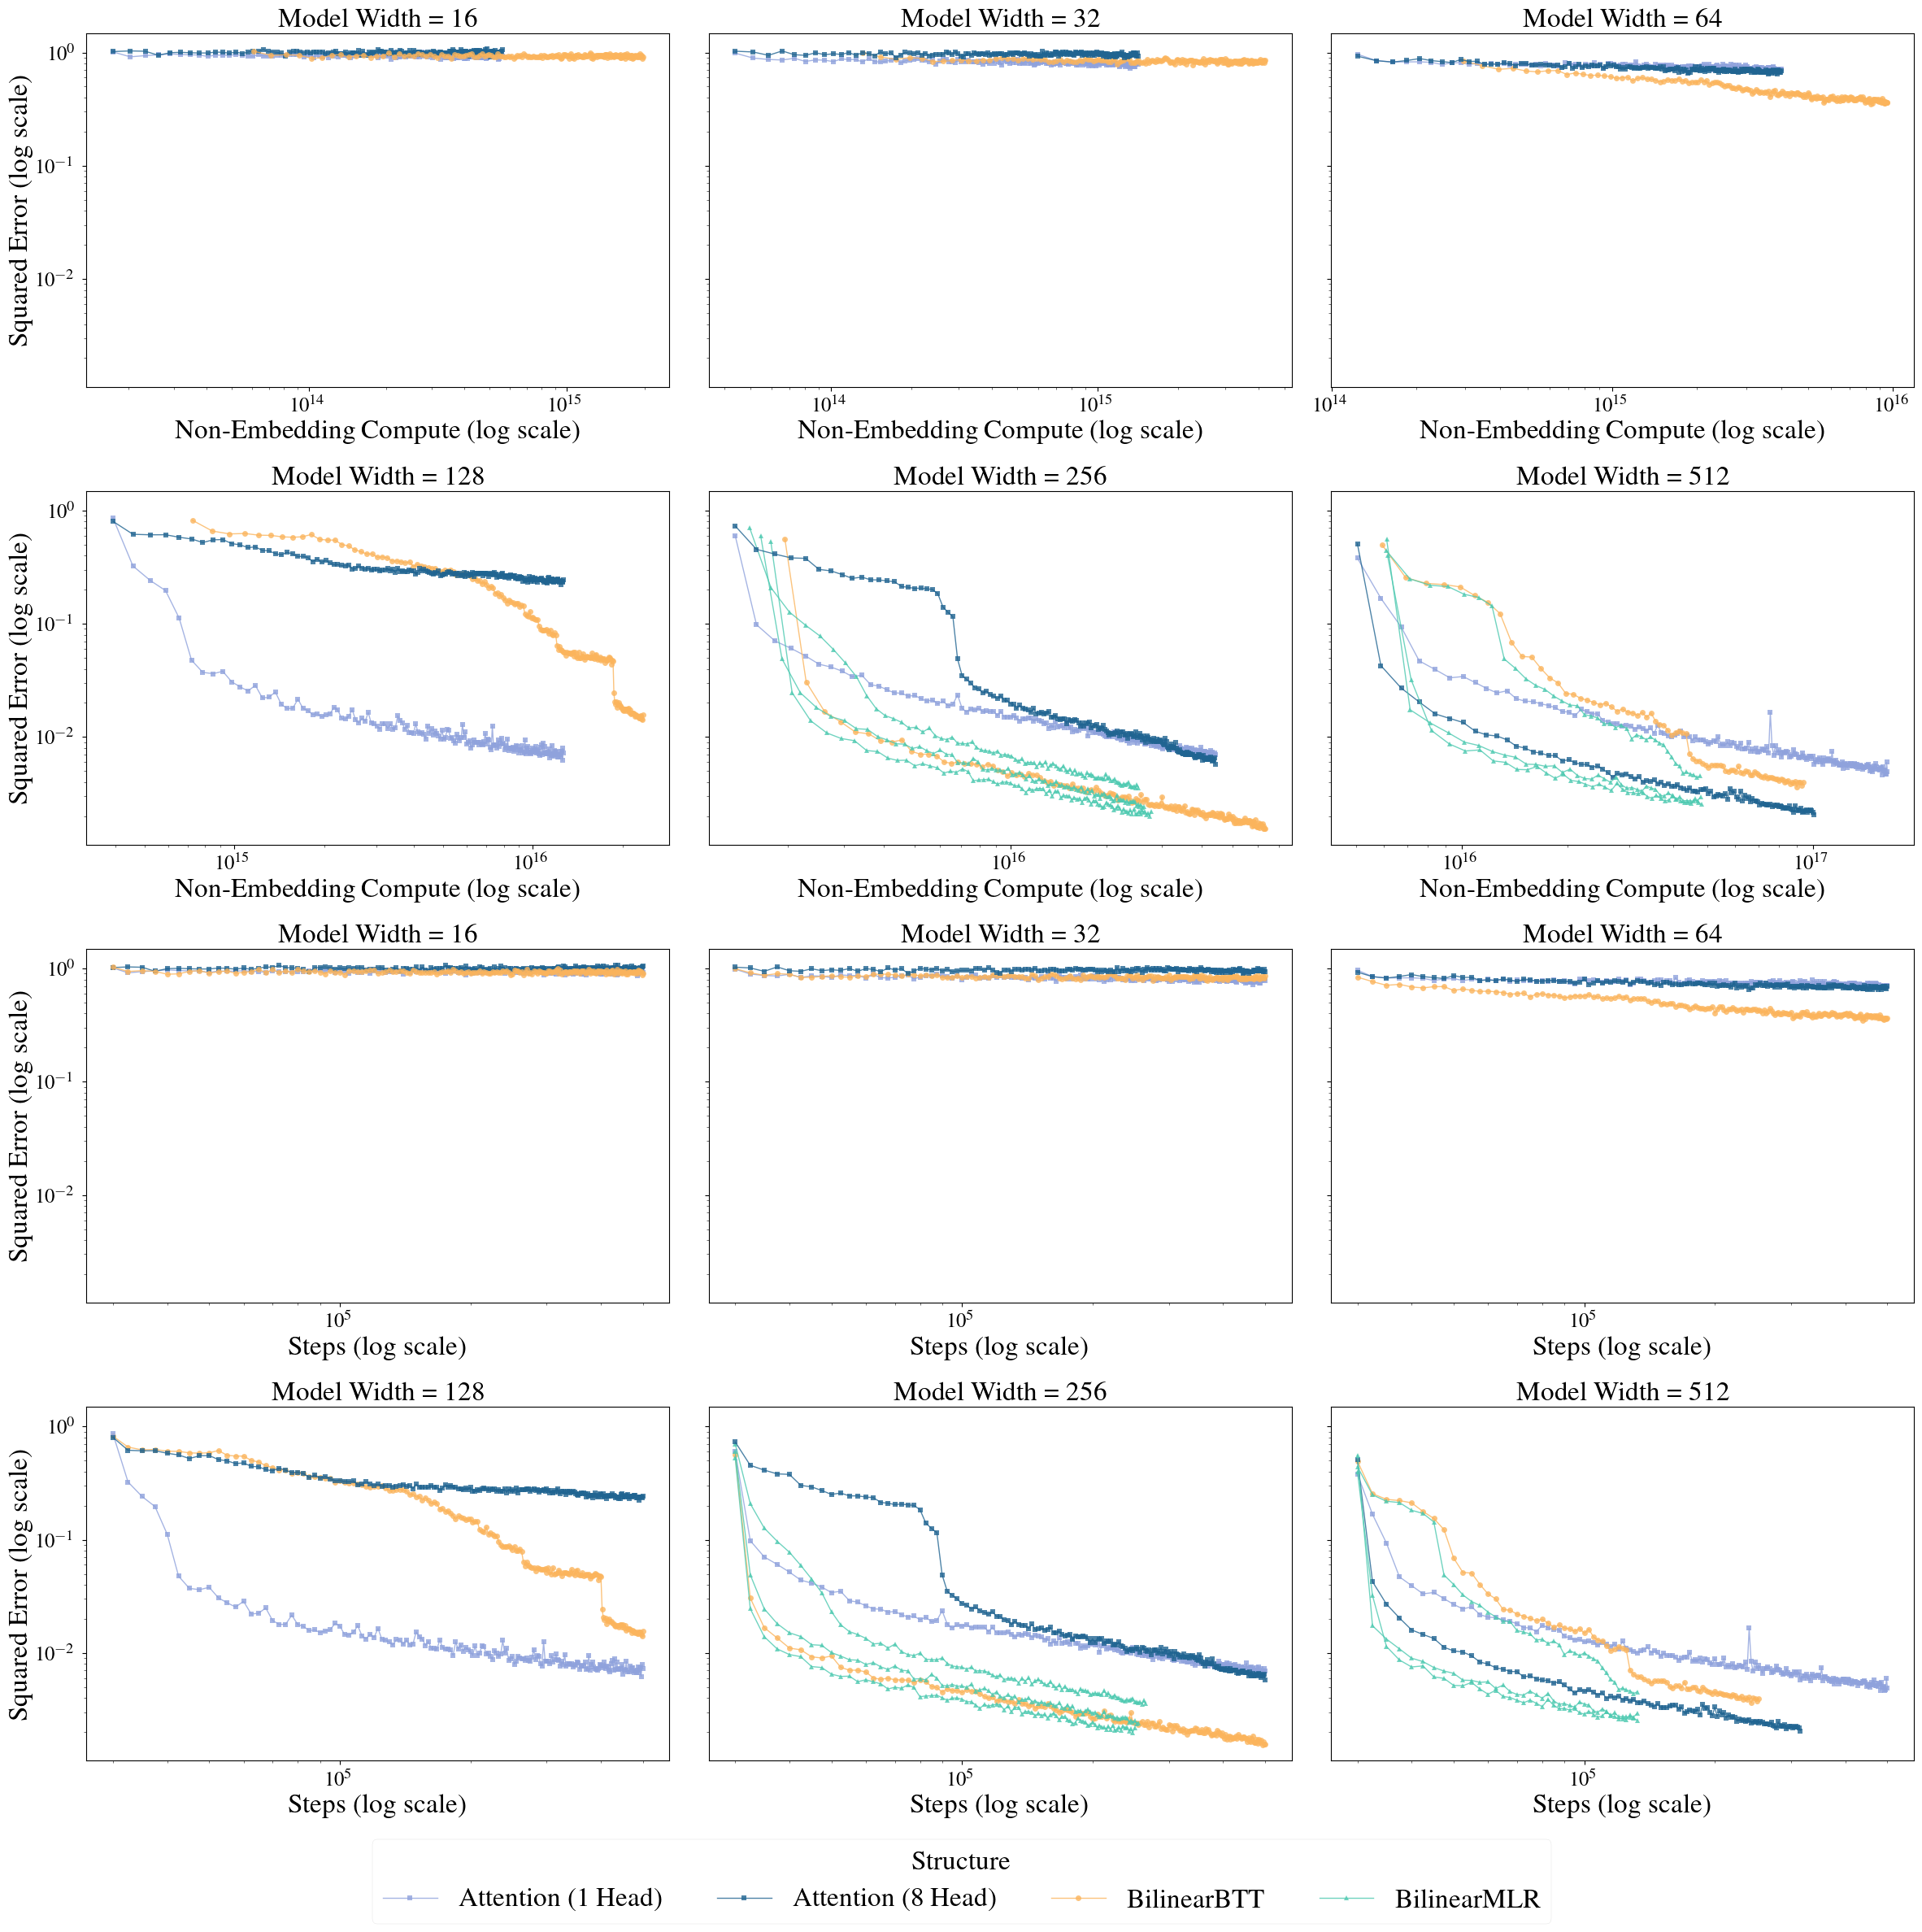

ndims_128+dm_16 | steps = 189
ndims_128+dm_16 | steps = 189
ndims_128+dm_16 | steps = 189
ndims_128+dm_32 | steps = 189
ndims_128+dm_32 | steps = 189
ndims_128+dm_32 | steps = 128
ndims_128+dm_64 | steps = 189
ndims_128+dm_64 | steps = 186
ndims_128+dm_64 | steps = 121
ndims_128+dm_128 | steps = 189
ndims_128+dm_128 | steps = 131
ndims_128+dm_128 | steps = 109
ndims_128+dm_256 | steps = 189
ndims_128+dm_256 | steps = 79
ndims_128+dm_256 | steps = 84
ndims_128+dm_512 | steps = 139
ndims_128+dm_512 | steps = 88
ndims_128+dm_512 | steps = 47


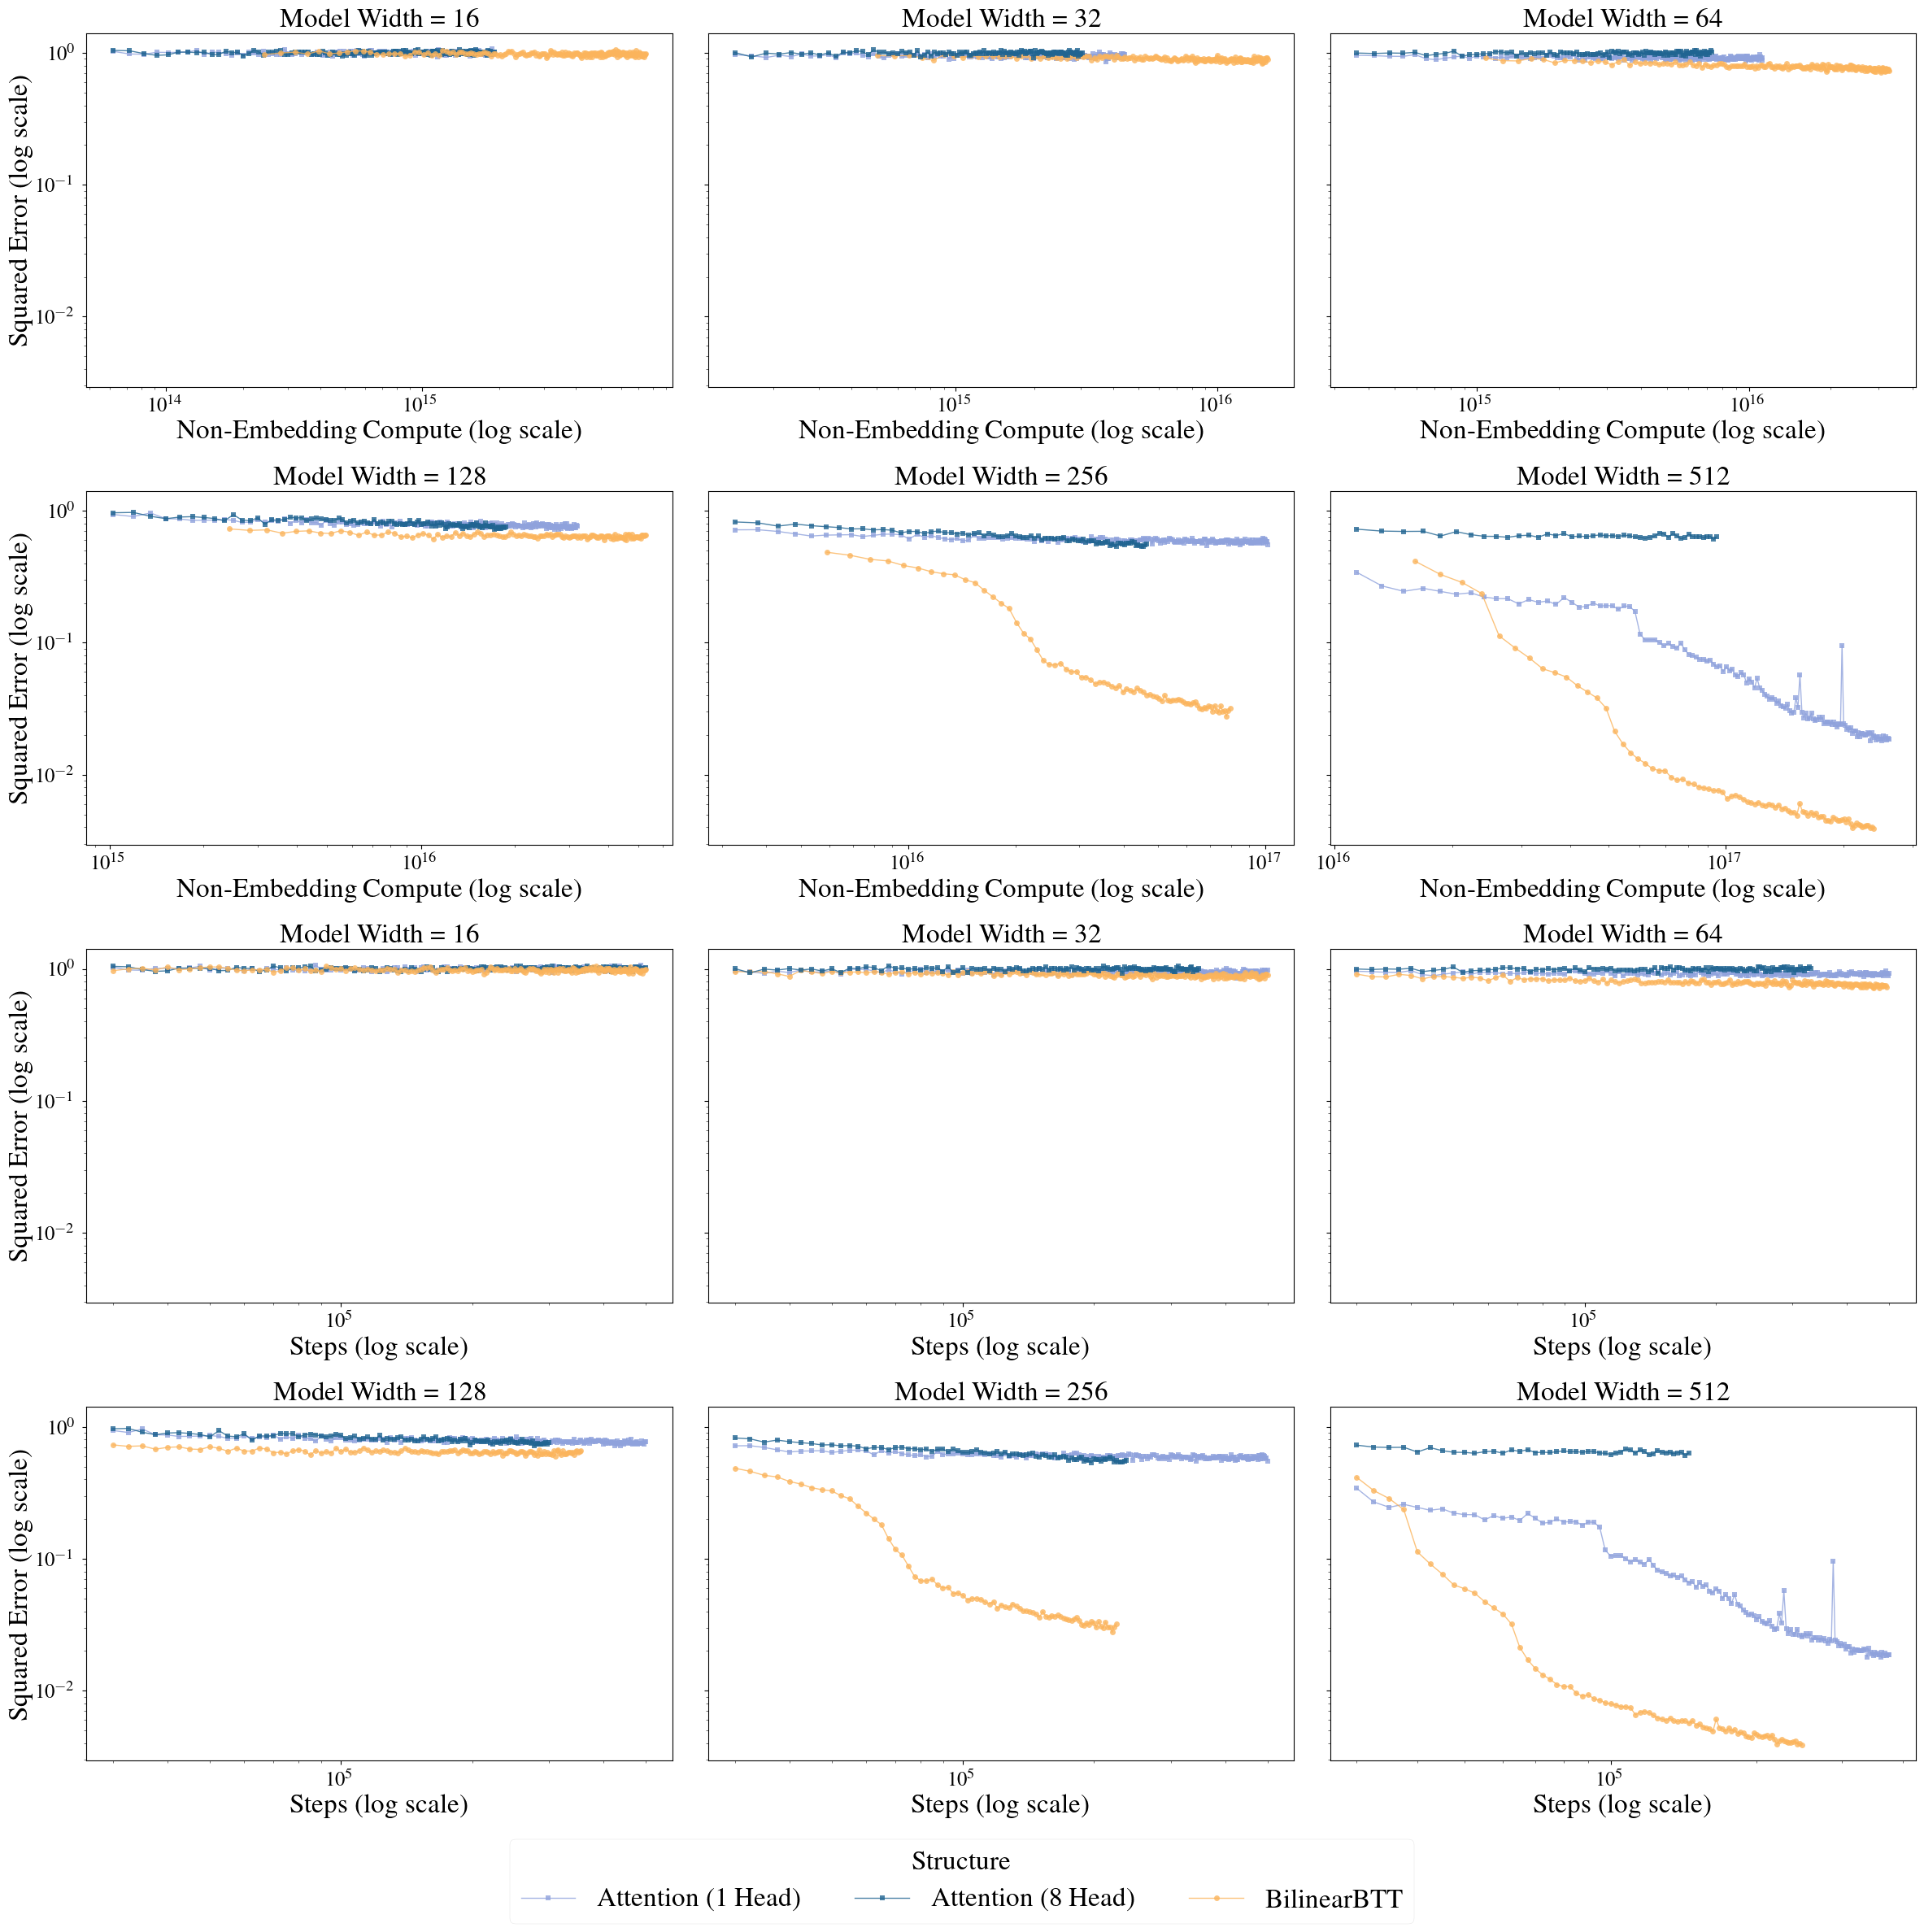

In [69]:
list_of_token_mixing_struct = ['BilinearBTT', 'LowRank', 'MLR']
list_of_ndims = [f"ndims_{i}" for i in [16, 32, 64, 128]]
list_of_dm = [f"dm_{i}" for i in [16, 32, 64, 128, 256, 512]]

# Define a better color palette | Melody | https://github.com/SabrinaSun1225/ChromaPalette
color_palette = {
    "BilinearBTT": "#FBB45C",  
    "LowRank_1h": "#8FA2DC",      
    "LowRank_8h": "#206491",     
    "MLR": "#4CC9B0",
    # "MLR": "#4CC9B0",
    # "MLR": "#81D0BB"          
}

# Mapping keys to legend-friendly names
legend_mapping = {
    "BilinearBTT": "BilinearBTT",
    "LowRank_1h": "Attention (1 Head)",
    "LowRank_8h": "Attention (8 Head)",
    "MLR": "BilinearMLR"
}

list_of_ndims = ['ndims_16', 'ndims_32', 'ndims_64', 'ndims_128']

for ndims in list_of_ndims:
    fig, axes = plt.subplots(4, 3, figsize=(24, 24), sharex=False, sharey=True)
    axes = axes.flatten()  # Flatten the axes array for easier indexing

    for i, dm in enumerate(list_of_dm):
        # Create two subplots for each dm: one for loss vs. steps and one for loss vs. non-embedding compute
        ax_loss_steps = axes[i+6]
        ax_loss_compute = axes[i]

        for key in all_data:
            if ndims in key and dm in key:
                if 'eval/non_emb_compute' not in all_data[key] or '_step' not in all_data[key]:
                    print(f"Key error | {key}")
                else:
                    print(f"{ndims}+{dm} | steps = {len(all_data[key]['eval/non_emb_compute'])}")

                    # Assign colors and markers for different structures
                    if "BilinearBTT" in key:
                        color, marker = color_palette["BilinearBTT"], "o"
                        legend_label = legend_mapping["BilinearBTT"]
                    elif "LowRank" in key:
                        if "nh_1" in key:
                            color, marker = color_palette["LowRank_1h"], "s"
                            legend_label = legend_mapping["LowRank_1h"]
                        elif "nh_8" in key:
                            color, marker = color_palette["LowRank_8h"], "s"
                            legend_label = legend_mapping["LowRank_8h"]
                    elif "MLR" in key:
                        color, marker = color_palette["MLR"], "^"
                        legend_label = legend_mapping["MLR"]
                    else:
                        raise ValueError

                    # Plot loss vs. steps
                    ax_loss_steps.loglog(
                        all_data[key]['_step'],
                        all_data[key][f"eval_pointwise/loss.{int(ndims.split('_')[-1]) * 2 - 1}"],
                        label=legend_label,
                        color=color,
                        marker=marker,
                        markersize=5,
                        linewidth=1,
                        alpha=0.8
                    )

                    # Plot loss vs. non-embedding compute
                    ax_loss_compute.loglog(
                        all_data[key]['eval/non_emb_compute'],
                        all_data[key][f"eval_pointwise/loss.{int(ndims.split('_')[-1]) * 2 - 1}"],
                        label=legend_label,
                        color=color,
                        marker=marker,
                        markersize=5,
                        linewidth=1,
                        alpha=0.8
                    )

        # Titles and labels for both subplots
        # ax_loss_steps.set_title(f"Loss vs. Steps\nModel Width = {dm.split('_')[-1]}")
        ax_loss_steps.set_xlabel("Steps (log scale)", fontsize=24)
        if i % 3 == 0:
            ax_loss_steps.set_ylabel("Squared Error (log scale)", fontsize=24)

        # ax_loss_compute.set_title(f"Loss vs. Compute\nModel Width = {dm.split('_')[-1]}")
        ax_loss_compute.set_xlabel("Non-Embedding Compute (log scale)", fontsize=24)
        
        if i % 3 == 0:
            ax_loss_compute.set_ylabel("Squared Error (log scale)", fontsize=24)

        ax_loss_steps.set_title(f"Model Width = {dm.split('_')[-1]}", fontsize=24)
        ax_loss_compute.set_title(f"Model Width = {dm.split('_')[-1]}", fontsize=24)

    # Adjust layout and add a shared legend
    handles, labels = [], []
    for ax in axes:
        ax_handles, ax_labels = ax.get_legend_handles_labels()
        handles.extend(ax_handles)
        labels.extend(ax_labels)

        # Increase the size of the x-ticks and y-ticks
        ax.tick_params(axis='both', which='major', labelsize=18)  # Major ticks
        ax.tick_params(axis='both', which='minor', labelsize=18)  # Minor ticks

    by_label = dict(zip(labels, handles))

    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="lower center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=4,
        title="Structure",
        fontsize=24,
        title_fontsize=24,
    )
    # fig.suptitle(f"Input Dimension = {ndims.split('_')[-1]}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle

    plt.savefig(f"rank_bottleneck_in_low_rank_{ndims}.pdf", dpi=300, bbox_inches="tight")
    plt.show()



In [70]:
list_of_token_mixing_struct_for_plotting = ['BilinearBTT','LowRank_1h','LowRank_8h']
list_of_token_mixing_struct = ['BilinearBTT','LowRank']

list_of_ndims = [f"ndims_{i}" for i in [16, 32, 64, 128]]
# list_of_dm = [f"dm_{i}" for i in [16, 32, 64, 128, 256, 512, 1024]]
# list_of_dm = [f"dm_{i}" for i in [16, 32, 64, 128, 256]]
list_of_dm = [f"dm_{i}" for i in [16, 32, 64, 128, 256, 512]]


# 1) dict_of_max_steps
dict_of_max_steps = {
    token_mixing_struct: {
        ndims: {
            dm: None for dm in list_of_dm
        } for ndims in list_of_ndims
    } for token_mixing_struct in list_of_token_mixing_struct_for_plotting
}
for token_mixing_struct in list_of_token_mixing_struct:
    for ndims in list_of_ndims:    
        for dm in list_of_dm:
            for key in all_data:
                if ndims in key and dm in key and token_mixing_struct in key:
                    if token_mixing_struct == "LowRank":
                        if "nh_8" in key:
                            dict_of_max_steps["LowRank_8h"][ndims][dm] = len(all_data[key]['eval/non_emb_compute'])
                        elif "nh_1" in key: 
                            dict_of_max_steps["LowRank_1h"][ndims][dm] = len(all_data[key]['eval/non_emb_compute'])
                        else:
                            raise ValueError
                    elif token_mixing_struct == "BilinearBTT":
                        dict_of_max_steps["BilinearBTT"][ndims][dm] = len(all_data[key]['eval/non_emb_compute'])
                    else:
                        raise ValueError


# 2) dict_of_min_steps_at_ndims
dict_of_min_steps_at_ndims = {
    token_mixing_struct: {
        ndims: {
            None
        } for ndims in list_of_ndims
    } for token_mixing_struct in list_of_token_mixing_struct_for_plotting
}
for token_mixing_struct in list_of_token_mixing_struct_for_plotting:
    for ndims in list_of_ndims:    
        min_step_at_ndims = 500000

        # obtain min_step_at_ndims
        for dm in dict_of_max_steps[token_mixing_struct][ndims]:
            if dict_of_max_steps[token_mixing_struct][ndims][dm] == None:
                continue
                
            if dict_of_max_steps[token_mixing_struct][ndims][dm]<min_step_at_ndims:
                    
                # if dict_of_max_steps[token_mixing_struct][ndims][dm]<=10:
                #     pass
                # else:
                min_step_at_ndims = dict_of_max_steps[token_mixing_struct][ndims][dm]

                # if ndims == "ndims_32":
                #     min_step_at_ndims=50

        # print(f"min_step_at_ndims={min_step_at_ndims}")

        dict_of_min_steps_at_ndims[token_mixing_struct][ndims] = min_step_at_ndims

        
# 3) dict_of_squared_error_at_min_steps                        
dict_of_squared_error_at_min_steps = {
    token_mixing_struct: {
        ndims: {
            dm: None for dm in list_of_dm
        } for ndims in list_of_ndims
    } for token_mixing_struct in list_of_token_mixing_struct_for_plotting
}

for token_mixing_struct in list_of_token_mixing_struct_for_plotting:
    for ndims in list_of_ndims:

        curr_min_step = dict_of_min_steps_at_ndims[token_mixing_struct][ndims]
        print(f"curr_min_step={curr_min_step} | token_mixing_struct={token_mixing_struct} | ndims={ndims}")
        for dm in list_of_dm:
            for key in all_data:
                if token_mixing_struct == "LowRank_8h":
                    curr_token_mixing_struct = "LowRank"
                    n_head_condition = "nh_8"
                elif token_mixing_struct == "LowRank_1h":
                    curr_token_mixing_struct = "LowRank"
                    n_head_condition = "nh_1"
                elif token_mixing_struct == "BilinearBTT":
                    curr_token_mixing_struct = "BilinearBTT"
                    n_head_condition = "nh_8"

                if ndims in key and dm in key and curr_token_mixing_struct in key and n_head_condition in key:
                    if curr_token_mixing_struct == "LowRank":
                        if "nh_8" in key:
                            dict_of_squared_error_at_min_steps["LowRank_8h"][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                        elif "nh_1" in key: 
                            dict_of_squared_error_at_min_steps["LowRank_1h"][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                        else:
                            raise ValueError
                    elif curr_token_mixing_struct == "BilinearBTT":
                        dict_of_squared_error_at_min_steps["BilinearBTT"][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                    else:
                        raise ValueError

                    # try:
                    #     dict_of_squared_error_at_min_steps[token_mixing_struct][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                    # except:
                    #     print(f"fail to retrieve value for {key}")
                        
# (Operations) dict_of_min_steps_at_ndims_across_structures
dict_of_min_steps_at_ndims_across_structures = {    
    ndims: 100000 for ndims in list_of_ndims
}

for token_mixing_struct in dict_of_min_steps_at_ndims:
    for ndims in dict_of_min_steps_at_ndims[token_mixing_struct]:
        if dict_of_min_steps_at_ndims[token_mixing_struct][ndims] < dict_of_min_steps_at_ndims_across_structures[ndims]:
            dict_of_min_steps_at_ndims_across_structures[ndims] = dict_of_min_steps_at_ndims[token_mixing_struct][ndims]

# (Operations) dict_of_squared_error_at_min_steps_control_steps_between_structures
dict_of_squared_error_at_min_steps_control_steps_between_structures = {
    token_mixing_struct: {
        ndims: {
            dm: None for dm in list_of_dm
        } for ndims in list_of_ndims
    } for token_mixing_struct in list_of_token_mixing_struct_for_plotting
}

for token_mixing_struct in list_of_token_mixing_struct:
    for ndims in list_of_ndims:

        curr_min_step = dict_of_min_steps_at_ndims_across_structures[ndims]
        # print(f"curr_min_step={curr_min_step}")
        for dm in list_of_dm:
            for key in all_data:
                if ndims in key and dm in key and token_mixing_struct in key:
                    if token_mixing_struct == "LowRank":
                        if "nh_8" in key:
                            dict_of_squared_error_at_min_steps_control_steps_between_structures["LowRank_8h"][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                        elif "nh_1" in key: 
                            dict_of_squared_error_at_min_steps_control_steps_between_structures["LowRank_1h"][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                        else:
                            raise ValueError
                    elif token_mixing_struct == "BilinearBTT":
                        dict_of_squared_error_at_min_steps_control_steps_between_structures["BilinearBTT"][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                    else:
                        raise ValueError

                    # try:
                    #     dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims][dm] = all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"][curr_min_step-1]
                    # except:
                    #     print(f"fail to retrieve value for {key}")


curr_min_step=191 | token_mixing_struct=BilinearBTT | ndims=ndims_16
curr_min_step=189 | token_mixing_struct=BilinearBTT | ndims=ndims_32
curr_min_step=90 | token_mixing_struct=BilinearBTT | ndims=ndims_64
curr_min_step=79 | token_mixing_struct=BilinearBTT | ndims=ndims_128
curr_min_step=191 | token_mixing_struct=LowRank_1h | ndims=ndims_16
curr_min_step=189 | token_mixing_struct=LowRank_1h | ndims=ndims_32
curr_min_step=189 | token_mixing_struct=LowRank_1h | ndims=ndims_64
curr_min_step=139 | token_mixing_struct=LowRank_1h | ndims=ndims_128
curr_min_step=191 | token_mixing_struct=LowRank_8h | ndims=ndims_16
curr_min_step=189 | token_mixing_struct=LowRank_8h | ndims=ndims_32
curr_min_step=115 | token_mixing_struct=LowRank_8h | ndims=ndims_64
curr_min_step=47 | token_mixing_struct=LowRank_8h | ndims=ndims_128


In [71]:
dict_of_max_steps

{'BilinearBTT': {'ndims_16': {'dm_16': 191,
   'dm_32': 191,
   'dm_64': 191,
   'dm_128': 191,
   'dm_256': 191,
   'dm_512': 191},
  'ndims_32': {'dm_16': 189,
   'dm_32': 189,
   'dm_64': 189,
   'dm_128': 189,
   'dm_256': 189,
   'dm_512': 189},
  'ndims_64': {'dm_16': 189,
   'dm_32': 189,
   'dm_64': 189,
   'dm_128': 189,
   'dm_256': 189,
   'dm_512': 90},
  'ndims_128': {'dm_16': 189,
   'dm_32': 189,
   'dm_64': 186,
   'dm_128': 131,
   'dm_256': 79,
   'dm_512': 88}},
 'LowRank_1h': {'ndims_16': {'dm_16': 191,
   'dm_32': 191,
   'dm_64': 191,
   'dm_128': 191,
   'dm_256': 191,
   'dm_512': 191},
  'ndims_32': {'dm_16': 189,
   'dm_32': 189,
   'dm_64': 189,
   'dm_128': 189,
   'dm_256': 189,
   'dm_512': 189},
  'ndims_64': {'dm_16': 189,
   'dm_32': 189,
   'dm_64': 189,
   'dm_128': 189,
   'dm_256': 189,
   'dm_512': 189},
  'ndims_128': {'dm_16': 189,
   'dm_32': 189,
   'dm_64': 189,
   'dm_128': 189,
   'dm_256': 189,
   'dm_512': 139}},
 'LowRank_8h': {'ndims_16'

In [72]:
dict_of_min_steps_at_ndims

{'BilinearBTT': {'ndims_16': 191,
  'ndims_32': 189,
  'ndims_64': 90,
  'ndims_128': 79},
 'LowRank_1h': {'ndims_16': 191,
  'ndims_32': 189,
  'ndims_64': 189,
  'ndims_128': 139},
 'LowRank_8h': {'ndims_16': 191,
  'ndims_32': 189,
  'ndims_64': 115,
  'ndims_128': 47}}

In [73]:
dict_of_min_steps_at_ndims_across_structures

{'ndims_16': 191, 'ndims_32': 189, 'ndims_64': 90, 'ndims_128': 47}

In [74]:
dict_of_squared_error_at_min_steps

{'BilinearBTT': {'ndims_16': {'dm_16': 0.5902220606803894,
   'dm_32': 0.005526155233383179,
   'dm_64': 0.001738622086122632,
   'dm_128': 0.001489178859628737,
   'dm_256': 0.0010782545432448387,
   'dm_512': 0.0007614013738930225},
  'ndims_32': {'dm_16': 0.7812380790710449,
   'dm_32': 0.5368754863739014,
   'dm_64': 0.005844327621161938,
   'dm_128': 0.0016809320077300072,
   'dm_256': 0.0010999299120157957,
   'dm_512': 0.0011078002862632275},
  'ndims_64': {'dm_16': 0.9631830453872681,
   'dm_32': 0.8714869618415833,
   'dm_64': 0.4298577606678009,
   'dm_128': 0.08753244578838348,
   'dm_256': 0.002407202497124672,
   'dm_512': 0.003974385093897581},
  'ndims_128': {'dm_16': 0.9781381487846375,
   'dm_32': 0.8942911028862,
   'dm_64': 0.7982616424560547,
   'dm_128': 0.6317855715751648,
   'dm_256': 0.03206906467676163,
   'dm_512': 0.004286636132746935}},
 'LowRank_1h': {'ndims_16': {'dm_16': 0.7532173991203308,
   'dm_32': 0.010197626426815987,
   'dm_64': 0.00678537925705313

In [75]:
dict_of_squared_error_at_min_steps_control_steps_between_structures

{'BilinearBTT': {'ndims_16': {'dm_16': 0.5902220606803894,
   'dm_32': 0.005526155233383179,
   'dm_64': 0.001738622086122632,
   'dm_128': 0.001489178859628737,
   'dm_256': 0.0010782545432448387,
   'dm_512': 0.0007614013738930225},
  'ndims_32': {'dm_16': 0.7812380790710449,
   'dm_32': 0.5368754863739014,
   'dm_64': 0.005844327621161938,
   'dm_128': 0.0016809320077300072,
   'dm_256': 0.0010999299120157957,
   'dm_512': 0.0011078002862632275},
  'ndims_64': {'dm_16': 0.9631830453872681,
   'dm_32': 0.8714869618415833,
   'dm_64': 0.4298577606678009,
   'dm_128': 0.08753244578838348,
   'dm_256': 0.002407202497124672,
   'dm_512': 0.003974385093897581},
  'ndims_128': {'dm_16': 0.9656988382339478,
   'dm_32': 0.9339946508407593,
   'dm_64': 0.7953153252601624,
   'dm_128': 0.6473559737205505,
   'dm_256': 0.03895112872123718,
   'dm_512': 0.005657198838889599}},
 'LowRank_1h': {'ndims_16': {'dm_16': 0.7532173991203308,
   'dm_32': 0.010197626426815987,
   'dm_64': 0.00678537925705

In [76]:
# # for token_mixing_struct in dict_of_squared_error_at_min_steps_control_steps_between_structures:
# #     for ndims in dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct]:
# #         dm_keys = list(dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys())
# #         for dm in dm_keys:
# #             if dm == "dm_256":
# #                 dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].pop(dm)
# #             if dm == "dm_1024":
# #                 dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].pop(dm)

# colors_MLR_1levels = ["#C6D3E7", "#7E86A7", "#6571A3", "#364377"]
# colors_MLR_8levels = ["#ECD4CC", "#E2BABC", "#C58A93", "#A1656D"]
# colors_LR_GSWA = ["#D9F1F0", "#AEDCDC", "#6EB0AF", "#4B8384"]
# colors_LR_SWA = ["#FFE4D6", "#FFC5A3", "#FF9F6D", "#E2703C"]


# # Mapping keys to legend-friendly names
# legend_mapping = {
#     "BilinearBTT": "BilinearBTT",
#     "LowRank_1h": "Attention (1 Head)",
#     "LowRank_8h": "Attention (8 Head)",
#     "MLR": "BilinearMLR"
# }

# color_palette = {
#     "BilinearBTT": "#4B8384",  
#     "LowRank_1h": "#E2703C",      
#     "LowRank_8h": "#364377", 
#     "MLR": "#A1656D",
#     # "MLR": "#81D0BB"
# }


# for ndims in list_of_ndims:
#     print(f"ndims={ndims}")
    
#     fig, ax = plt.subplots(figsize=(10, 8))
#     d_input = int(ndims.split("_")[-1])

#     for token_mixing_struct in dict_of_squared_error_at_min_steps_control_steps_between_structures:
#         if token_mixing_struct == "BilinearBTT":
#             marker="o"
#             color=color_palette["BilinearBTT"]

#             final_r = d_input

#         elif token_mixing_struct == "LowRank_8h":
#             marker="s"
#             color=color_palette["LowRank_8h"]

#             final_r = d_input * 8
#             ax.axvline(x=final_r, color=color, linestyle='--', linewidth=1.5) #, alpha=0.5)            
#         elif token_mixing_struct == "LowRank_1h":
#             marker="s"
#             color=color_palette["LowRank_1h"]

#             final_r = d_input
#             # ax.axvline(x=final_r+0.0001, color=color, linestyle='--', linewidth=1.5, alpha=0.5)

#         else:
#             raise ValueError

#         ax.plot(
#             list(map(lambda x: int(x.split("_")[-1]), dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys())),
#             dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values(),
#             marker=marker,
#             color=color,
#             label=legend_mapping[token_mixing_struct],
#             linewidth=4.5,
#         )
        
#     # Add titles and labels
#     ax.set_title(f"Input Dimension =  {ndims.split("_")[-1]}", fontsize=24)
#     ax.set_xlabel("Model Width D (Log Scale)", fontsize=24)
#     ax.set_ylabel("Squared Error", fontsize=24)
#     ax.set_xscale("log")
#     # ax.set_yscale("log")
#     ax.grid(True)
    
#     # Increase the size of the x-ticks and y-ticks
#     ax.tick_params(axis='both', which='major', labelsize=18)  # Major ticks
#     ax.tick_params(axis='both', which='minor', labelsize=18)  # Minor ticks

#     # # Show legend
#     # ax.legend(title="Structure", loc="upper right")

#     # Adjust layout and add a shared legend
#     handles, labels = [], []
#     for ax in axes:
#         ax_handles, ax_labels = ax.get_legend_handles_labels()
#         handles.extend(ax_handles)
#         labels.extend(ax_labels)
#         print(f"ax_labels={ax_labels}")

#         # Increase the size of the x-ticks and y-ticks
#         ax.tick_params(axis='both', which='major', labelsize=18)  # Major ticks
#         ax.tick_params(axis='both', which='minor', labelsize=18)  # Minor ticks

#     by_label = dict(zip(labels, handles))

#     fig.legend(
#         by_label.values(),
#         by_label.keys(),
#         loc="lower center",
#         bbox_to_anchor=(0.5, -0.2),
#         ncol=4,
#         title="Structure",
#         fontsize=18,
#         title_fontsize=18,
#     )

#     # Adjust layout
#     plt.tight_layout()

#     # Save the plot for this ndims
#     plt.savefig(f"final_loss_{ndims}_as_a_function_of_params.png", dpi=300, bbox_inches="tight")
#     plt.show()


ndims=ndims_16


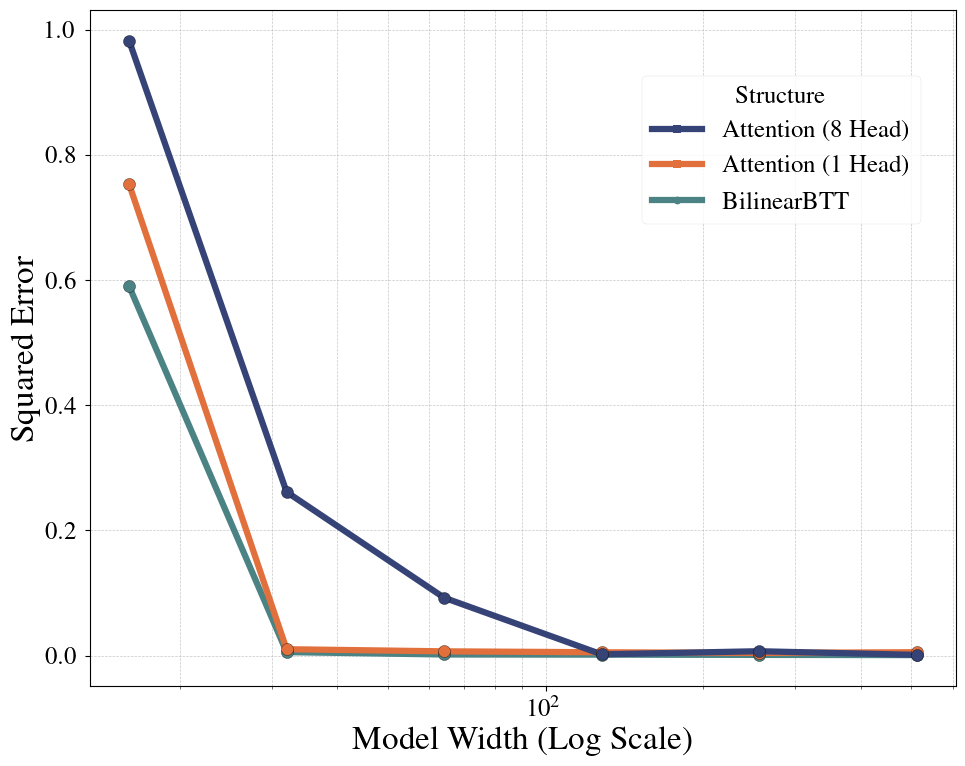

ndims=ndims_32


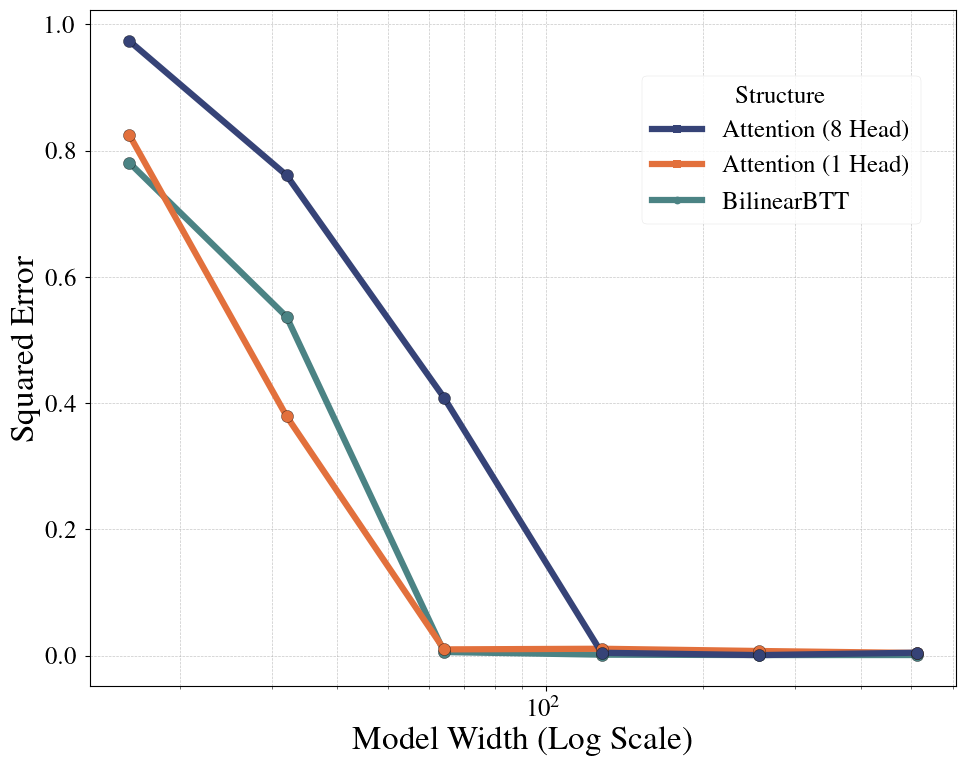

ndims=ndims_64


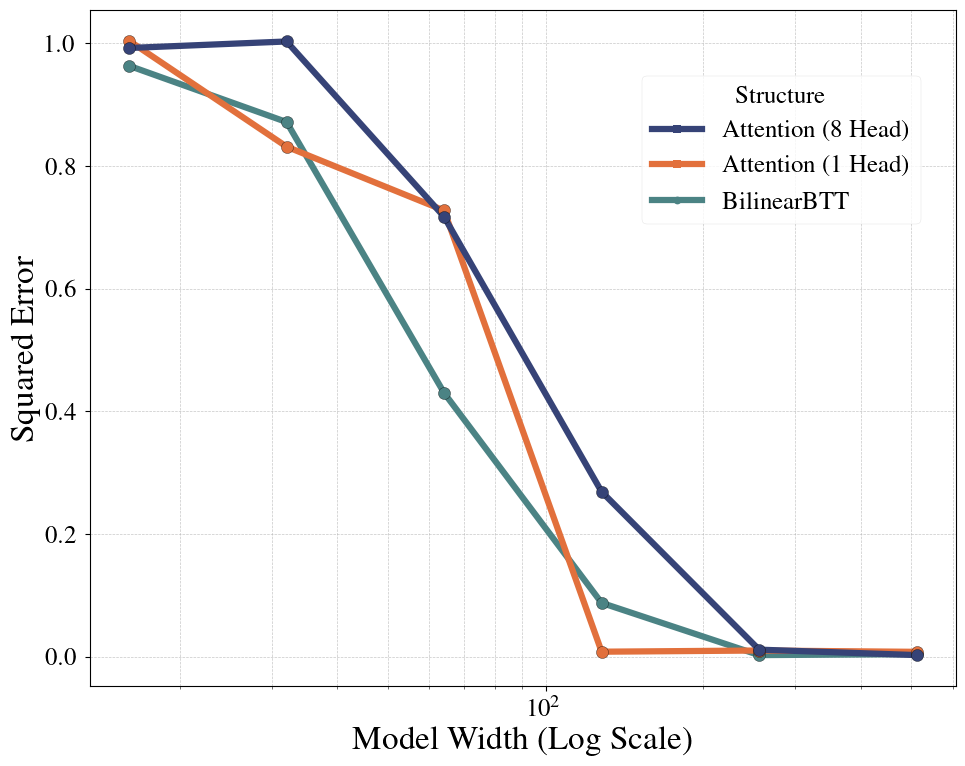

ndims=ndims_128


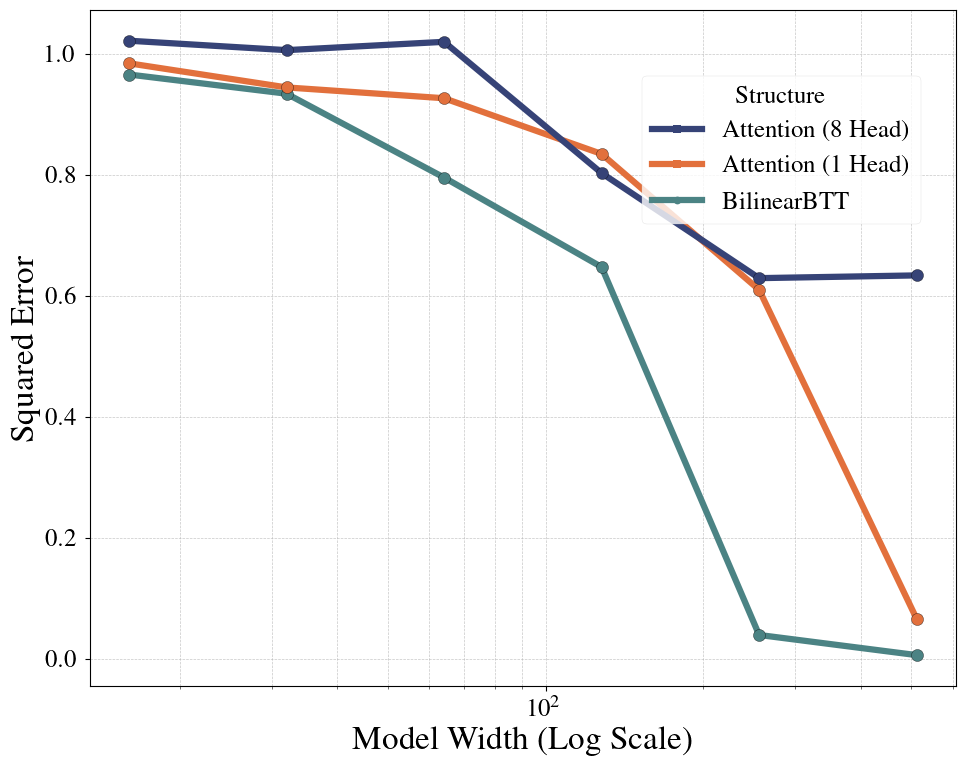

In [84]:
# for token_mixing_struct in dict_of_squared_error_at_min_steps_control_steps_between_structures:
#     for ndims in dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct]:
#         dm_keys = list(dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys())
#         for dm in dm_keys:
#             if dm == "dm_256":
#                 dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].pop(dm)
#             if dm == "dm_1024":
#                 dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].pop(dm)

colors_MLR_1levels = ["#C6D3E7", "#7E86A7", "#6571A3", "#364377"]
colors_MLR_8levels = ["#ECD4CC", "#E2BABC", "#C58A93", "#A1656D"]
colors_LR_GSWA = ["#D9F1F0", "#AEDCDC", "#6EB0AF", "#4B8384"]
colors_LR_SWA = ["#FFE4D6", "#FFC5A3", "#FF9F6D", "#E2703C"]


# Mapping keys to legend-friendly names
legend_mapping = {
    "BilinearBTT": "BilinearBTT",
    "LowRank_1h": "Attention (1 Head)",
    "LowRank_8h": "Attention (8 Head)",
    "MLR": "BilinearMLR"
}

color_palette = {
    "BilinearBTT": "#4B8384",  
    "LowRank_1h": "#E2703C",      
    "LowRank_8h": "#364377", 
    "MLR": "#A1656D",
    # "MLR": "#81D0BB"
}
for ndims in list_of_ndims:
    print(f"ndims={ndims}")
    
    fig, ax = plt.subplots(figsize=(10, 8))
    d_input = int(ndims.split("_")[-1])

    for token_mixing_struct in dict_of_squared_error_at_min_steps_control_steps_between_structures:
        if token_mixing_struct == "BilinearBTT":
            marker = "o"
            color = color_palette["BilinearBTT"]
            final_r = d_input

        elif token_mixing_struct == "LowRank_8h":
            marker = "s"
            color = color_palette["LowRank_8h"]
            final_r = d_input * 8
            # ax.axvline(x=final_r, color=color, linestyle='--', linewidth=1.5)

        elif token_mixing_struct == "LowRank_1h":
            marker = "s"
            color = color_palette["LowRank_1h"]
            final_r = d_input

        else:
            raise ValueError

        # Ensure the label matches the legend_mapping
        label = legend_mapping[token_mixing_struct]

        ax.plot(
            list(map(lambda x: int(x.split("_")[-1]), dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys())),
            dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values(),
            marker=marker,
            color=color,
            label=label,  # Add label for legend
            linewidth=4.5,
        )
        ax.scatter(
            list(map(lambda x: int(x.split("_")[-1]), dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys())), 
            dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values(),
            color=color, s=75, edgecolor="black", facecolor=color, zorder=3)

    # Add titles and labels
    # ax.set_title(f"Input Dimension = {ndims.split('_')[-1]}", fontsize=24)
    ax.set_xlabel("Model Width (Log Scale)", fontsize=24)
    ax.set_ylabel("Squared Error", fontsize=24)
    ax.set_xscale("log")
    ax.grid(visible=True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

    # Increase the size of ticks
    ax.tick_params(axis='both', labelsize=18)

    # Gather handles and labels for legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    
    # Desired order of keys
    desired_order = ['Attention (8 Head)', 'Attention (1 Head)', 'BilinearBTT']
    
    # Sort the dictionary based on the desired order
    by_label = {key: by_label[key] for key in desired_order if key in by_label}

    fig.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper right",
        bbox_to_anchor=(0.95, 0.9),

        # loc="lower center",
        # bbox_to_anchor=(0.5, -0.1),
        # ncol=4,
        title="Structure",
        fontsize=18,
        title_fontsize=18,
    )

    # Adjust layout
    plt.tight_layout()

    # Save the plot
    plt.savefig(f"final_loss_{ndims}_as_a_function_of_params.pdf", dpi=300, bbox_inches="tight")
    plt.show()


In [61]:
dict_of_squared_error_at_min_steps

{'BilinearBTT': {'ndims_16': {'dm_16': 0.5902220606803894,
   'dm_32': 0.005526155233383179,
   'dm_64': 0.001738622086122632,
   'dm_128': 0.001489178859628737,
   'dm_256': 0.0010782545432448387,
   'dm_512': 0.0007614013738930225,
   'dm_1024': 0.0009458364802412689},
  'ndims_32': {'dm_16': 0.7917962074279785,
   'dm_32': 0.5852357745170593,
   'dm_64': 0.015399680472910404,
   'dm_128': 0.002973346970975399,
   'dm_256': 0.00157872901763767,
   'dm_512': 0.0017659185687080026,
   'dm_1024': 0.00094788265414536},
  'ndims_64': {'dm_16': 0.923519492149353,
   'dm_32': 0.8174477219581604,
   'dm_64': 0.4414251744747162,
   'dm_128': 0.08939637243747711,
   'dm_256': 0.002539847744628787,
   'dm_512': 0.004004213027656078,
   'dm_1024': 0.0020577397663146257},
  'ndims_128': {'dm_16': 0.9811676740646362,
   'dm_32': 0.948826014995575,
   'dm_64': 0.7759767770767212,
   'dm_128': 0.6920915246009827,
   'dm_256': 0.047001585364341736,
   'dm_512': 0.006568836513906717,
   'dm_1024': 0.0

In [69]:
# dict_of_squared_error_at_min_steps

In [74]:
# # Set a professional style for publication
# plt.style.use('seaborn-v0_8-paper')

# # dict_of_squared_error_at_min_steps_control_steps_between_structures

# # Initialize the figure for a 2x2 grid of subplots
# fig, axs = plt.subplots(2, 2, figsize=(12, 10))  # Adjust size as needed
# fig.subplots_adjust(hspace=0.35, wspace=0.3)  # Adjust spacing between subplots

# token_mixing_struct = 'LowRank_8h'  # Single token mixing structure

# # Define scientific color scheme
# line_color = "#1034A6"
# marker_edge_color = "#1034A6"
# marker_face_color = "#1034A6"

# for i, ndims in enumerate(list_of_ndims):
#     row, col = divmod(i, 2)  # Determine subplot position in a 2x2 grid
#     ax = axs[row, col]       # Get the corresponding axis
    
#     # Extract data for the current `ndims`
#     xs = np.arange(0, len(dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values()))
#     ys = dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values()
    

#     # Calculate ratios using `list_of_dm`
#     list_of_ratios = list(
#         map(
#             lambda x: int(int(x.split("_")[-1]) / 8) / int(ndims.split("_")[-1]),
#             list(dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys()),
#         )
#     )

#     # Plot with updated aesthetics
#     ax.plot(xs, ys, label="Squared Error", color=line_color, linewidth=2.25)
#     ax.scatter(xs, ys, edgecolor=marker_edge_color, facecolor=marker_face_color, s=40, zorder=3)

#     ax.set_xticks(xs)
#     ax.set_xticklabels(list_of_ratios, rotation=45, ha='right', fontsize=10)

#     if 1.0 in list_of_ratios:
#         x_val_for_vline = np.where(np.array(list_of_ratios)==1.0)
#         # print(x_val_for_vline[0][0])
#         ax.axvline(x=x_val_for_vline[0][0], color='grey', linestyle='--', linewidth=1.5, label='x=5')

#     # Set labels and title for each subplot
#     ax.set_xlabel("Rank Ratio", fontsize=12)
#     ax.set_ylabel("Squared Error", fontsize=12)
#     ax.set_title(f"Input Dimension = {ndims.split('_')[-1]}", fontsize=14)

#     ax.set_ylim([0, 1.1])
#     ax.grid(visible=True, which='major', linestyle='--', linewidth=0.6, alpha=0.7)
#     ax.yaxis.set_major_locator(MaxNLocator(5))  # Limit the number of y-ticks

# # Add a global figure title
# fig.suptitle("Rank Bottleneck in Multi-Head Attention", fontsize=16, weight='bold')

# # Save the combined figure with tight layout
# # plt.savefig("rank_bottleneck_ratio_in_low_rank_combined_beautiful.png", dpi=300, bbox_inches="tight")
# plt.show()


In [75]:
list_of_token_mixing_struct

['BilinearBTT', 'LowRank']

/var/folders/cd/g1xby3jd50511c3784lhly9c0000gn/T/ipykernel_72619/1278693343.py:53: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0, 2])


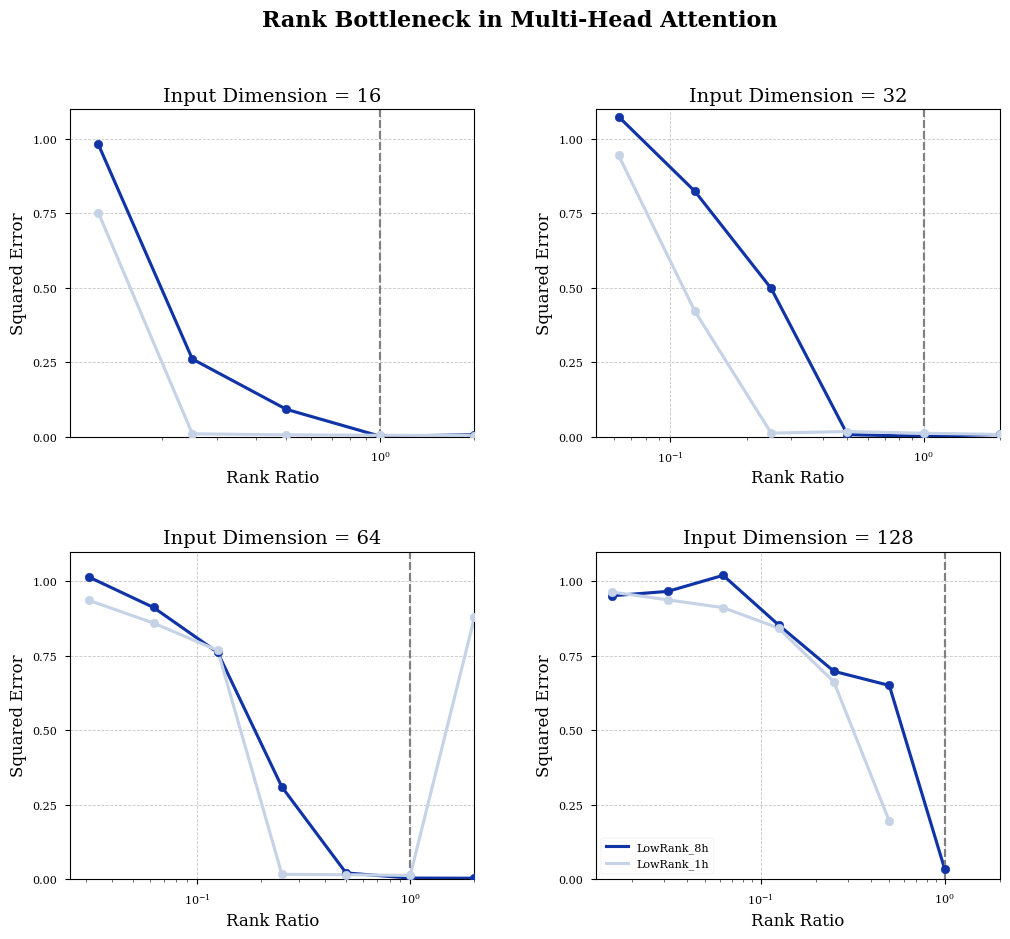

In [86]:
# Set a professional style for publication
plt.style.use('seaborn-v0_8-paper')

# Initialize the figure for a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 10))  # Adjust size as needed
fig.subplots_adjust(hspace=0.35, wspace=0.3)  # Adjust spacing between subplots

# token_mixing_struct = 'LowRank_8h'  # Single token mixing structure

list_of_line_color = ["#1034A6", "#C6D3E7"]
for i, token_mixing_struct in enumerate(['LowRank_8h', 'LowRank_1h']):
    # Define scientific color scheme
    line_color = list_of_line_color[i]
    marker_edge_color = list_of_line_color[i]
    marker_face_color = list_of_line_color[i]
    
    for i, ndims in enumerate(list_of_ndims):
        row, col = divmod(i, 2)  # Determine subplot position in a 2x2 grid
        ax = axs[row, col]       # Get the corresponding axis
        
        # Extract data for the current `ndims`
        xs = np.arange(0, len(dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values()))
        ys = dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].values()
        
    
        # Calculate ratios using `list_of_dm`
        list_of_ratios = list(
            map(
                lambda x: int(int(x.split("_")[-1]) / 8) / int(ndims.split("_")[-1]),
                list(dict_of_squared_error_at_min_steps_control_steps_between_structures[token_mixing_struct][ndims].keys()),
            )
        )
    
        # Plot with updated aesthetics
        ax.plot(list_of_ratios, ys, label=token_mixing_struct, color=line_color, linewidth=2.25)
        ax.scatter(list_of_ratios, ys, edgecolor=marker_edge_color, facecolor=marker_face_color, s=40, zorder=3)
    
        # ax.set_xticks(xs)
        # ax.set_xticklabels(list_of_ratios, rotation=45, ha='right', fontsize=10)
    
        if 1.0 in list_of_ratios:
            x_val_for_vline = np.where(np.array(list_of_ratios)==1.0)
            # print(x_val_for_vline[0][0])
            ax.axvline(x=1.0, color='grey', linestyle='--', linewidth=1.5)

        ax.set_xscale('log')
        # Set labels and title for each subplot
        ax.set_xlabel("Rank Ratio", fontsize=12)
        ax.set_ylabel("Squared Error", fontsize=12)
        ax.set_title(f"Input Dimension = {ndims.split('_')[-1]}", fontsize=14)
    
        ax.set_ylim([0, 1.1])
        ax.set_xlim([0, 2])
        ax.grid(visible=True, which='major', linestyle='--', linewidth=0.6, alpha=0.7)
        ax.yaxis.set_major_locator(MaxNLocator(5))  # Limit the number of y-ticks
        
        
    # Add a global figure title
    fig.suptitle("Rank Bottleneck in Multi-Head Attention", fontsize=16, weight='bold')

plt.legend()
# Save the combined figure with tight layout
# plt.savefig("four_rank_bottleneck_ratio_in_low_rank_combined_beautiful.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/cd/g1xby3jd50511c3784lhly9c0000gn/T/ipykernel_72619/1160897931.py:50: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim([0, 1.1])


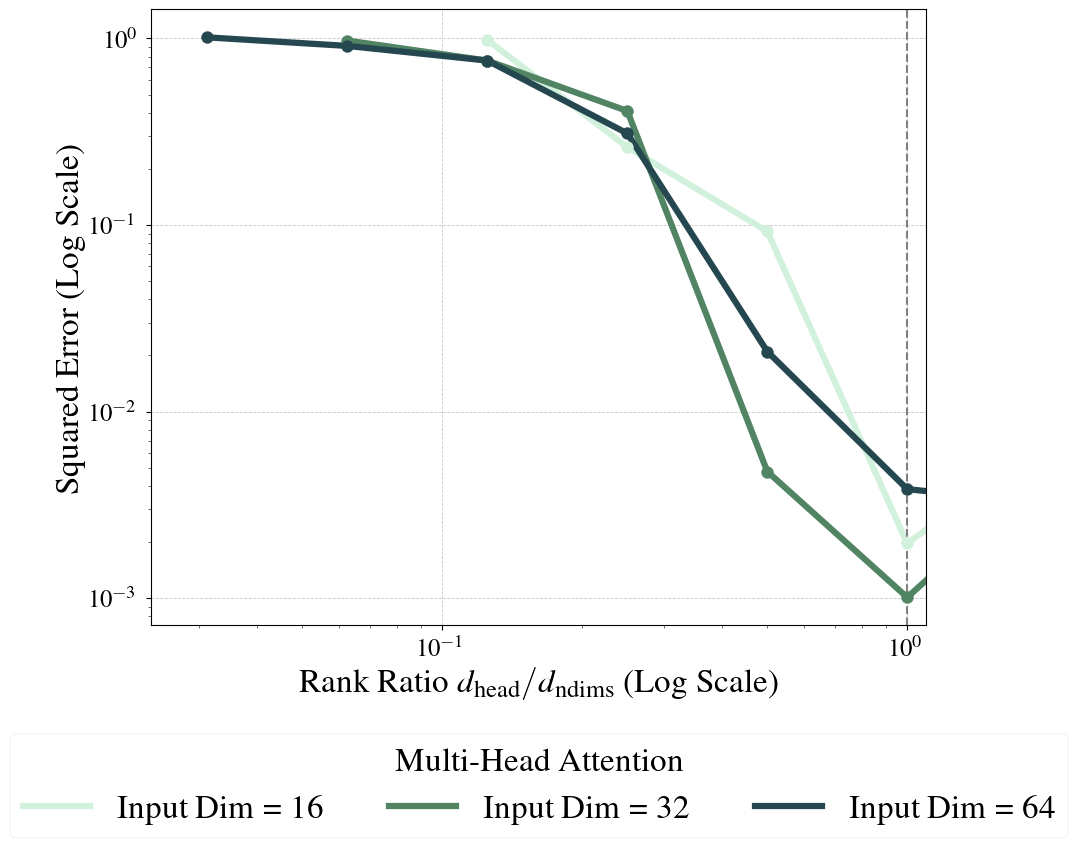

In [88]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator, LogLocator

list_of_ndims = ['ndims_16', 'ndims_32', 'ndims_64']
plt.style.use('seaborn-v0_8-paper')

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif=['Times'])

# Initialize the figure
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust size as needed

colors = [
    '#d2f1dc',
    '#518463',
    '#254750',
    #d2f1dc,#518463,#254750
]

# Token mixing structure
token_mixing_struct = 'LowRank_8h'

# Plot each data series in a single plot
for i, (ndims, color) in enumerate(zip(list_of_ndims, colors)):
    # Extract data for the current `ndims`
    xs = np.arange(0, len(dict_of_squared_error_at_min_steps[token_mixing_struct][ndims].values()))
    ys = dict_of_squared_error_at_min_steps[token_mixing_struct][ndims].values()

    # Calculate ratios using `list_of_dm`
    list_of_ratios = list(
        map(
            lambda x: int(int(x.split("_")[-1]) / 8) / int(ndims.split("_")[-1]),
            list(dict_of_squared_error_at_min_steps[token_mixing_struct][ndims].keys()),
        )
    )

    # Plot line and scatter points
    ax.loglog(list_of_ratios, ys, label=f"Input Dim = {ndims.split('_')[-1]}", color=color, linewidth=4.5)
    ax.scatter(list_of_ratios, ys, edgecolor=color, facecolor=color, s=75, zorder=3)

# Add vertical line if ratio includes 1.0
ax.axvline(x=1, color="grey", linestyle='--', linewidth=1.5)

# Add labels, title, and legend
ax.set_xlabel(r"Rank Ratio $d_{\mathrm{head}}/d_{\mathrm{ndims}}$ (Log Scale)", fontsize=24)
ax.set_ylabel("Squared Error (Log Scale)", fontsize=24)

# Adjust x-axis limits and add grid
ax.set_xlim([0, 1.1])
ax.grid(visible=True, which='major', linestyle='--', linewidth=0.6, alpha=0.7)

# Add more y-axis ticks
# ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))

# Set font size for ticks
ax.tick_params(axis='both', which='major', labelsize=18)  # Adjust labelsize as needed

# Add legend outside the plot
ax.legend(title="Multi-Head Attention", title_fontsize=24, loc='upper center', fontsize=24, ncol=len(list_of_ndims), bbox_to_anchor=(0.5, -0.15))

# Save the combined figure with tight layout
plt.savefig("rank_bottleneck_combined_beautiful.pdf", dpi=300, bbox_inches="tight")
plt.show()


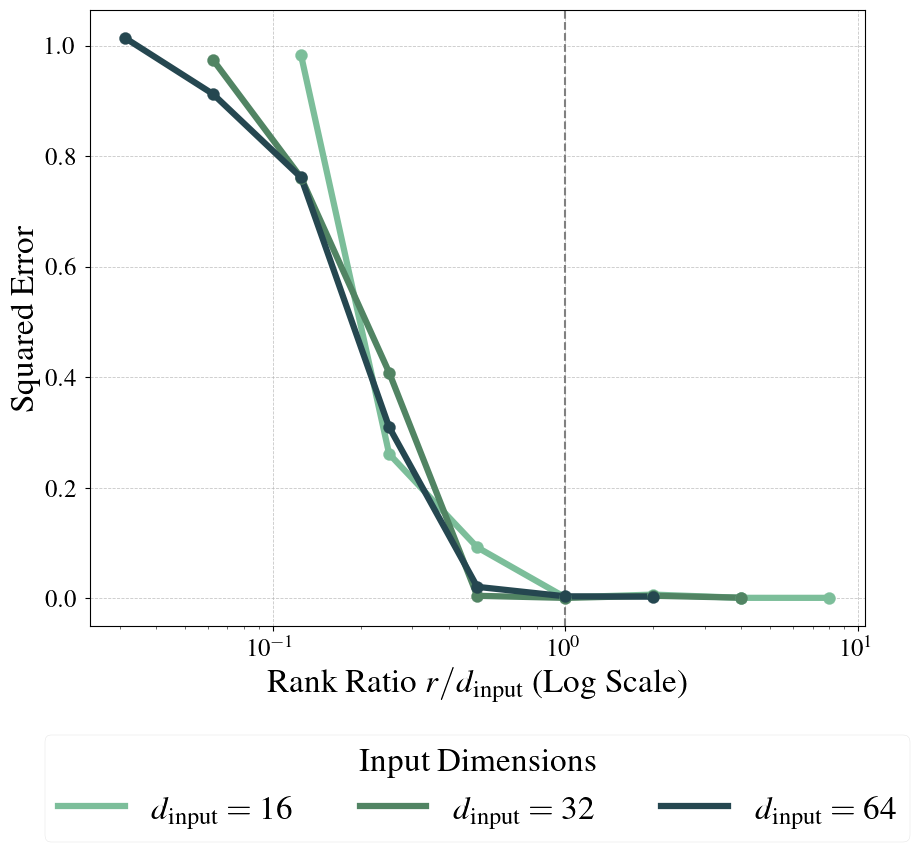

In [105]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator, LogLocator

list_of_ndims = ['ndims_16', 'ndims_32', 'ndims_64']
plt.style.use('seaborn-v0_8-paper')

plt.rc('text', usetex=True)
plt.rc('font', family='serif', serif=['Times'])

# Initialize the figure
fig, ax = plt.subplots(figsize=(10, 8))  # Adjust size as needed

colors = [
    # '#d2f1dc',
    '#7cbe9a',
    '#518463',
    '#254750',
    #d2f1dc,#518463,#254750
]

# Token mixing structure
token_mixing_struct = 'LowRank_8h'

# Plot each data series in a single plot
for i, (ndims, color) in enumerate(zip(list_of_ndims, colors)):
    # Extract data for the current `ndims`
    xs = np.arange(0, len(dict_of_squared_error_at_min_steps[token_mixing_struct][ndims].values()))
    ys = dict_of_squared_error_at_min_steps[token_mixing_struct][ndims].values()

    # Calculate ratios using `list_of_dm`
    list_of_ratios = list(
        map(
            lambda x: int(int(x.split("_")[-1]) / 8) / int(ndims.split("_")[-1]),
            list(dict_of_squared_error_at_min_steps[token_mixing_struct][ndims].keys()),
        )
    )

    # Plot line and scatter points
    ax.plot(list_of_ratios, ys, label=fr"$d_{{\mathrm{{input}}}} = {ndims.split("_")[-1]}$", color=color, linewidth=4.5)
    ax.scatter(list_of_ratios, ys, edgecolor=color, facecolor=color, s=75, zorder=3)

# Add vertical line if ratio includes 1.0
ax.axvline(x=1, color="grey", linestyle='--', linewidth=1.5)

# Add labels, title, and legend
ax.set_xlabel(r"Rank Ratio $r/d_{\mathrm{input}}$ (Log Scale)", fontsize=24)
ax.set_ylabel("Squared Error", fontsize=24)
ax.set_xscale("log")

# Adjust x-axis limits and add grid
# ax.set_xlim([0, 1.1])
ax.grid(visible=True, which='major', linestyle='--', linewidth=0.6, alpha=0.7)

# Add more y-axis ticks
# ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=10))

# Set font size for ticks
ax.tick_params(axis='both', which='major', labelsize=18)  # Adjust labelsize as needed

# Add legend outside the plot
ax.legend(title="Input Dimensions", title_fontsize=24, loc='upper center', fontsize=24, ncol=len(list_of_ndims), bbox_to_anchor=(0.5, -0.15))

# Save the combined figure with tight layout
plt.savefig("rank_bottleneck_combined_beautiful.pdf", dpi=300, bbox_inches="tight")
plt.show()


LowRank+ndims_64+dm_256 | steps = 189
LowRank+ndims_64+dm_256 | steps = 189
MLR+ndims_64+dm_256 | steps = 95
MLR+ndims_64+dm_256 | steps = 91
MLR+ndims_64+dm_256 | steps = 89
BilinearBTT+ndims_64+dm_256 | steps = 189


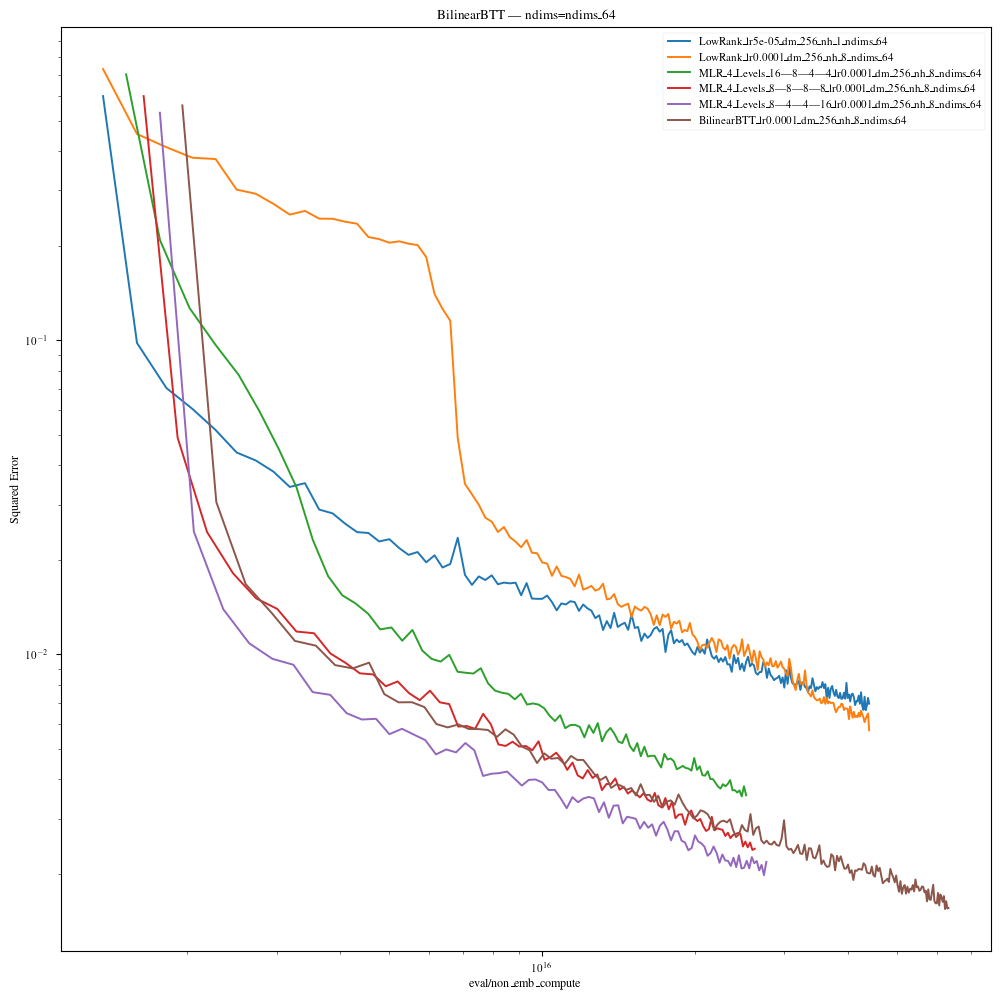

In [23]:
list_of_token_mixing_struct = ['LowRank', 'MLR', 'BilinearBTT']
list_of_ndims = ["ndims_64"] # [f"ndims_{i}" for i in [16, 64, 128, 256]]
list_of_dm = ["dm_256"] # [f"dm_{i}" for i in [16, 32, 64, 128, 256, 512, 1024]]

plt.figure(figsize=(12,12))
for token_mixing_struct in list_of_token_mixing_struct:
    for ndims in list_of_ndims:
        
    
        for dm in list_of_dm:
            for key in all_data:
                if ndims in key and dm in key and token_mixing_struct in key:
                    if 'eval/non_emb_compute' not in all_data[key]:
                        print(f"key error | {key}")
                    else:
                        print(f"{token_mixing_struct}+{ndims}+{dm} | steps = {len(all_data[key]['eval/non_emb_compute'])}")
                        
                        plt.loglog(all_data[key]['eval/non_emb_compute'], all_data[key][f"eval_pointwise/loss.{int(ndims.split("_")[-1])*2-1}"], label=key)
                        plt.xlabel("eval/non_emb_compute")
                        plt.ylabel("Squared Error")
                        plt.title(f"{token_mixing_struct} | ndims={ndims}")
plt.legend()
# plt.savefig(f"scaling_law_{ndims}_{list_of_dm}.png",dpi=300)

plt.show()

In [24]:
all_data.keys()

dict_keys(['LowRank_lr5e-05_dm_16_nh_1_ndims_64', 'LowRank_lr5e-05_dm_64_nh_1_ndims_64', 'BilinearBTT_lr2.5e-05_dm_32_nh_8_ndims_16', 'BilinearBTT_lr1e-05_dm_128_nh_8_ndims_64', 'LowRank_lr0.0001_dm_512_nh_1_ndims_32', 'LowRank_lr5e-05_dm_512_nh_1_ndims_128', 'LowRank_lr5e-05_dm_256_nh_1_ndims_128', 'LowRank_lr5e-05_dm_128_nh_1_ndims_128', 'LowRank_lr0.0001_dm_16_nh_1_ndims_128', 'LowRank_lr0.0001_dm_64_nh_1_ndims_128', 'LowRank_lr5e-05_dm_32_nh_1_ndims_128', 'LowRank_lr5e-05_dm_256_nh_1_ndims_32', 'LowRank_lr5e-05_dm_64_nh_1_ndims_32', 'LowRank_lr5e-05_dm_32_nh_1_ndims_32', 'LowRank_lr5e-05_dm_128_nh_1_ndims_32', 'LowRank_lr0.0001_dm_16_nh_1_ndims_32', 'LowRank_lr5e-05_dm_64_nh_1_ndims_16', 'LowRank_lr5e-05_dm_32_nh_1_ndims_16', 'LowRank_lr0.0001_dm_512_nh_1_ndims_16', 'LowRank_lr5e-05_dm_256_nh_1_ndims_64', 'BilinearBTT_lr0.0001_dm_1024_nh_8_ndims_32', 'BilinearBTT_lr0.0001_dm_512_nh_8_ndims_32', 'BilinearBTT_lr0.0001_dm_256_nh_8_ndims_32', 'BilinearBTT_lr5e-05_dm_128_nh_8_ndims_32',

LowRank+ndims_64+dm_256 | steps = 189
LowRank+ndims_64+dm_256 | steps = 189
MLR+ndims_64+dm_256 | steps = 95
MLR+ndims_64+dm_256 | steps = 91
MLR+ndims_64+dm_256 | steps = 89
BilinearBTT+ndims_64+dm_256 | steps = 189


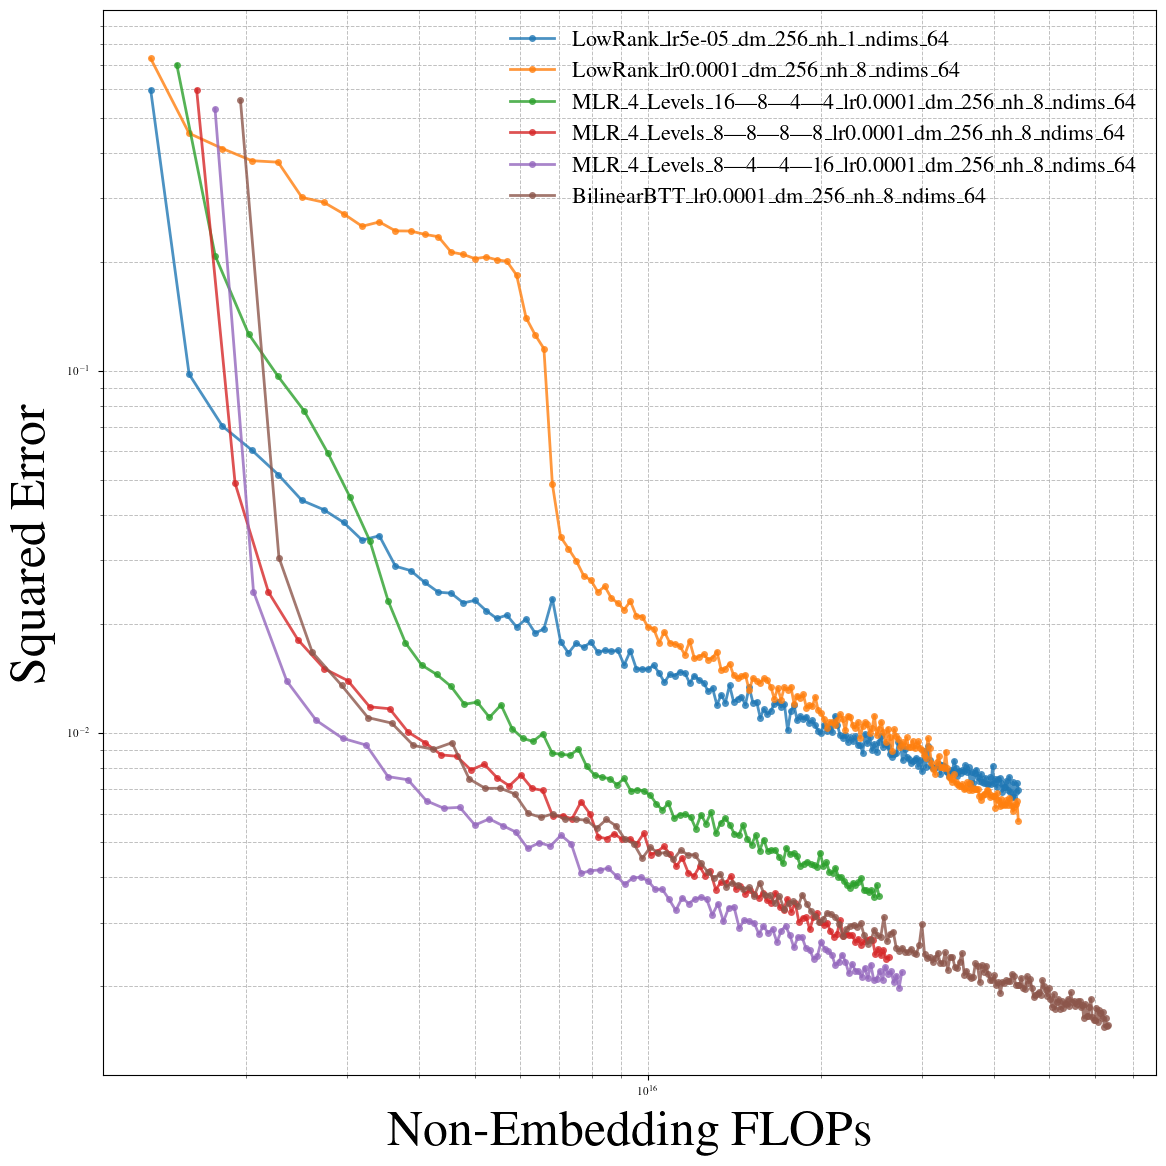

In [25]:
# Apply the seaborn-paper style
plt.style.use('seaborn-v0_8-paper')

plt.figure(figsize=(12, 12))
for token_mixing_struct in list_of_token_mixing_struct:
    # plt.figure(figsize=(8, 8))  # Separate figures for each structure to avoid overcrowding
    
    for ndims in list_of_ndims:
        for dm in list_of_dm:
            for key in all_data:
                if ndims in key and dm in key and token_mixing_struct in key:
                    if 'eval/non_emb_compute' not in all_data[key]:
                        print(f"key error | {key}")
                    else:
                        print(f"{token_mixing_struct}+{ndims}+{dm} | steps = {len(all_data[key]['eval/non_emb_compute'])}")
                        
                        plt.loglog(
                            all_data[key]['eval/non_emb_compute'],
                            all_data[key][f"eval_pointwise/loss.{int(ndims.split('_')[-1]) * 2 - 1}"],
                            label=key,
                            linewidth=2,
                            marker='o',
                            markersize=5,
                            alpha=0.8  # Adjust alpha for better overlapping visibility
                        )

plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.8)
plt.xlabel("Non-Embedding FLOPs", fontsize=36, labelpad=10)
plt.ylabel("Squared Error", fontsize=36, labelpad=10)
# plt.title(f"Scaling Laws: {token_mixing_struct} (ndims={ndims})", fontsize=32, pad=15)
plt.legend(loc='upper right', fontsize=16, frameon=False, title_fontsize=12)
plt.tight_layout()

# Uncomment this line to save the figures
plt.savefig(f"scaling_law_{ndims}_{list_of_dm}.png", dpi=300)
plt.show()
